# 🚖 Predicción de Demanda de Transporte — NYC TLC
> **Sistema de Deep Learning para predicción de demanda en rutas específicas (próximos 30 días)**

---

| Ítem | Detalle |
|---|---|
| **Dataset** | NYC TLC Trip Record Data |
| **Objetivo** | Predecir número de viajes por zona/ruta para los próximos 30 días |
| **Modelos** | Regresión Lineal · Random Forest · XGBoost · LSTM · Prophet |
| **Métricas** | RMSE · MAE · MAPE · R² |

---

## 📋 Tabla de Contenidos
1. [Instalación y Configuración](#1)
2. [Carga y Exploración de Datos (EDA)](#2)
3. [Preprocesamiento y Feature Engineering](#3)
4. [Análisis de Estacionalidad y Tendencias](#4)
5. [Modelo Base — Regresión Lineal](#5)
6. [Modelos de Ensamble — Random Forest & XGBoost](#6)
7. [Modelo de Deep Learning — LSTM](#7)
8. [Modelo Prophet (Series de Tiempo)](#8)
9. [Comparación de Modelos y Métricas](#9)
10. [Predicción Final: Próximos 30 Días](#10)
11. [Conclusiones y Recomendaciones](#11)

## 1. Instalación y Configuración <a id='1'></a>

In [38]:
# ── Instalación de librerías adicionales ──────────────────────────────────────
!pip install prophet xgboost pyarrow fastparquet holidays seaborn statsmodels scikit-learn tensorflow plotly -q

print('✅ Librerías instaladas correctamente')

✅ Librerías instaladas correctamente



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
# ── Importaciones ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import requests
from pathlib import Path
import shutil
import joblib
import pickle
import json
import gc
import os

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Series de tiempo y estadística
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# Scikit-learn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline

# XGBoost
import xgboost as xgb

# Prophet
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_plotly, plot_components_plotly

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization,
    Bidirectional, Conv1D, MaxPooling1D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Fechas y feriados
import holidays

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# ── Estilo de gráficas ────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']
sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print(f'✅ TensorFlow: {tf.__version__}')
print(f'✅ GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'✅ Entorno listo')

✅ TensorFlow: 2.21.0
✅ GPU disponible: False
✅ Entorno listo


## 2. Carga y Exploración de Datos (EDA) <a id='2'></a>

> **Dataset:** NYC TLC Yellow Taxi Trip Records  
> **Fuente:** https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page  
> **Formato:** Parquet (~año 2023, 12 meses)

In [40]:
# ── Descarga de datos (Yellow Taxi 2023) ──────────────────────────────────────
# Usamos el año 2023 completo para tener ~12 meses de historia

BASE_URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/'
MONTHS = range(1, 13)  # Enero a Diciembre 2023
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'modulo1'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / 'output' / 'modulo1'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = OUTPUT_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

dfs = []
for month in MONTHS:
    fname = f'yellow_tripdata_2023-{month:02d}.parquet'
    fpath = DATA_DIR / fname
    
    # 1. Descarga controlada
    if not fpath.exists():
        url = BASE_URL + fname
        print(f'⬇️ Descargando {fname}...')
        response = requests.get(url)
        if response.status_code == 200:
            with open(fpath, 'wb') as f:
                f.write(response.content)
            print(f'✅ {fname} descargado con éxito.')
        else:
            print(f'❌ Error al descargar {fname}. Código: {response.status_code}')
            continue # Saltamos este mes si no se puede descargar
    else:
        print(f'✅ {fname} ya existe, saltando descarga.')

    # 2. Solo intentamos leer si el archivo existe físicamente
    if fpath.exists():
        cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime',
                'PULocationID', 'DOLocationID', 'passenger_count',
                'trip_distance', 'fare_amount', 'tip_amount', 'total_amount']
        
        df_month = pd.read_parquet(fpath, columns=cols)
        df_month['month_src'] = month
        dfs.append(df_month)
        gc.collect()

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\n📦 Dataset completo: {df_raw.shape[0]:,} filas')

✅ yellow_tripdata_2023-01.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-02.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-03.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-04.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-05.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-06.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-07.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-08.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-09.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-10.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-11.parquet ya existe, saltando descarga.
✅ yellow_tripdata_2023-12.parquet ya existe, saltando descarga.

📦 Dataset completo: 38,310,226 filas


In [41]:
# ── Vista inicial del dataset ─────────────────────────────────────────────────
print('=== Primeras filas ===')
display(df_raw.head())

print('\n=== Tipos de datos ===')
print(df_raw.dtypes)

print('\n=== Estadísticas descriptivas ===')
display(df_raw.describe())

=== Primeras filas ===


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,month_src
0,2023-01-01 00:32:10,2023-01-01 00:40:36,161,141,1.0,0.97,9.3,0.00,14.30,1
1,2023-01-01 00:55:08,2023-01-01 01:01:27,43,237,1.0,1.10,7.9,4.00,16.90,1
2,2023-01-01 00:25:04,2023-01-01 00:37:49,48,238,1.0,2.51,14.9,15.00,34.90,1
3,2023-01-01 00:03:48,2023-01-01 00:13:25,138,7,0.0,1.90,12.1,0.00,20.85,1
4,2023-01-01 00:10:29,2023-01-01 00:21:19,107,79,1.0,1.43,11.4,3.28,19.68,1



=== Tipos de datos ===
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
PULocationID                      int64
DOLocationID                      int64
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
tip_amount                      float64
total_amount                    float64
month_src                         int64
dtype: object

=== Estadísticas descriptivas ===


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,month_src
count,38310226,38310226,3.831023e+07,3.831023e+07,3.700087e+07,3.831023e+07,3.831023e+07,3.831023e+07,3.831023e+07,3.831023e+07
mean,2023-07-02 22:47:58.448232,2023-07-02 23:04:41.459181,1.651755e+02,1.639500e+02,1.370426e+00,4.088946e+00,1.952225e+01,3.522265e+00,2.846194e+01,6.544286e+00
min,2001-01-01 00:06:49,1970-01-20 10:16:32,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.087300e+03,-4.110000e+02,-1.094050e+03,1.000000e+00
25%,2023-04-02 18:25:17,2023-04-02 18:43:06.250000,1.320000e+02,1.130000e+02,1.000000e+00,1.040000e+00,9.300000e+00,1.000000e+00,1.595000e+01,4.000000e+00
50%,2023-06-27 18:43:55,2023-06-27 18:59:09,1.620000e+02,1.620000e+02,1.000000e+00,1.790000e+00,1.350000e+01,2.800000e+00,2.100000e+01,6.000000e+00
75%,2023-10-06 21:55:14,2023-10-06 22:11:37,2.340000e+02,2.340000e+02,1.000000e+00,3.400000e+00,2.190000e+01,4.410000e+00,3.072000e+01,1.000000e+01
max,2024-01-03 19:42:57,2024-01-03 20:15:55,2.650000e+02,2.650000e+02,9.000000e+00,3.457294e+05,3.869836e+05,4.174000e+03,3.869876e+05,1.200000e+01
std,NaN,NaN,6.399765e+01,6.985543e+01,8.925924e-01,2.412509e+02,7.572729e+01,4.147060e+00,7.712821e+01,3.466931e+00


In [42]:
# ── Análisis de valores nulos ─────────────────────────────────────────────────
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
print('Porcentaje de valores nulos por columna:')
print(null_pct[null_pct > 0].to_string() if null_pct.sum() > 0 else 'Sin nulos')

# Distribución de LocationIDs (rutas)
print(f'\nZonas de origen únicas (PULocationID): {df_raw["PULocationID"].nunique()}')
print(f'Zonas de destino únicas (DOLocationID): {df_raw["DOLocationID"].nunique()}')
print(f'Rango de fechas: {df_raw["tpep_pickup_datetime"].min()} → {df_raw["tpep_pickup_datetime"].max()}')

Porcentaje de valores nulos por columna:
passenger_count    3.42

Zonas de origen únicas (PULocationID): 263
Zonas de destino únicas (DOLocationID): 262
Rango de fechas: 2001-01-01 00:06:49 → 2024-01-03 19:42:57


## 3. Preprocesamiento y Feature Engineering <a id='3'></a>

In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.1  LIMPIEZA DE DATOS
# ══════════════════════════════════════════════════════════════════════════════

df = df_raw.copy()

# Conversión de fechas
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Filtros de calidad
n_before = len(df)
df = df[
    (df['tpep_pickup_datetime'].dt.year  == 2023) &  # Solo 2023
    (df['passenger_count']  >= 1) &
    (df['passenger_count']  <= 6) &
    (df['trip_distance']    >  0) &
    (df['trip_distance']    <= 100) &
    (df['fare_amount']      >  0) &
    (df['fare_amount']      <= 500) &
    (df['total_amount']     >  0) &
    (df['PULocationID'].between(1, 263)) &
    (df['DOLocationID'].between(1, 263))
]

n_after = len(df)
print(f'Filas antes de limpieza: {n_before:,}')
print(f'Filas después de limpieza: {n_after:,}')
print(f'Registros eliminados: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.1f}%)')

Filas antes de limpieza: 38,310,226
Filas después de limpieza: 35,079,176
Registros eliminados: 3,231,050 (8.4%)


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.2  FEATURE ENGINEERING — Extracción de características temporales
# ══════════════════════════════════════════════════════════════════════════════

df['pickup_date']    = df['tpep_pickup_datetime'].dt.date
df['pickup_hour']    = df['tpep_pickup_datetime'].dt.hour
df['pickup_dow']     = df['tpep_pickup_datetime'].dt.dayofweek   # 0=Lun, 6=Dom
df['pickup_month']   = df['tpep_pickup_datetime'].dt.month
df['pickup_week']    = df['tpep_pickup_datetime'].dt.isocalendar().week.astype(int)
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.quarter
df['is_weekend']     = (df['pickup_dow'] >= 5).astype(int)
df['trip_duration']  = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Feriados de NY
us_holidays = holidays.US(state='NY', years=2023)
df['is_holiday'] = df['tpep_pickup_datetime'].dt.date.apply(
    lambda d: 1 if d in us_holidays else 0
)

# Franja horaria del día
def time_period(h):
    if 0  <= h < 6:  return 'madrugada'
    if 6  <= h < 12: return 'mañana'
    if 12 <= h < 18: return 'tarde'
    return 'noche'

df['time_period'] = df['pickup_hour'].apply(time_period)

print('✅ Features temporales creados:')
print([c for c in df.columns if c not in df_raw.columns])

✅ Features temporales creados:
['pickup_date', 'pickup_hour', 'pickup_dow', 'pickup_month', 'pickup_week', 'pickup_quarter', 'is_weekend', 'trip_duration', 'is_holiday', 'time_period']


In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.3  SELECCIÓN DE RUTAS PRINCIPALES
# Trabajamos con las Top-5 zonas de origen más concurridas
# para tener series de tiempo suficientemente densas
# ══════════════════════════════════════════════════════════════════════════════

TOP_N_ZONES = 5
top_zones = df['PULocationID'].value_counts().head(TOP_N_ZONES).index.tolist()

# Etiquetas descriptivas de zonas NYC (subset conocidas)
ZONE_NAMES = {
    237: 'Upper East Side North',
    161: 'Midtown Center',
    236: 'Upper East Side South',
    162: 'Midtown East',
    230: 'Times Sq / Theatre District',
    142: 'Lincoln Square East',
    186: 'Penn Station / Madison Sq',
    170: 'Murray Hill',
    138: 'LaGuardia Airport',
    132: 'JFK Airport',
}

print(f'Top {TOP_N_ZONES} zonas de origen:')
for z in top_zones:
    cnt = df[df['PULocationID'] == z].shape[0]
    name = ZONE_NAMES.get(z, f'Zone {z}')
    print(f'  Zone {z:3d} ({name}): {cnt:>10,} viajes')

Top 5 zonas de origen:
  Zone 132 (JFK Airport):  1,816,252 viajes
  Zone 237 (Upper East Side North):  1,698,360 viajes
  Zone 161 (Midtown Center):  1,670,461 viajes
  Zone 236 (Upper East Side South):  1,497,768 viajes
  Zone 162 (Midtown East):  1,287,170 viajes


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.4  AGREGACIÓN DIARIA POR ZONA
# Crear series de tiempo: número de viajes por día y zona
# ══════════════════════════════════════════════════════════════════════════════

# Filtrar y agrupar
df_zone = df[df['PULocationID'].isin(top_zones)].copy()

daily = (
    df_zone
    .groupby(['pickup_date', 'PULocationID'])
    .agg(
        trips           = ('tpep_pickup_datetime', 'count'),
        passengers      = ('passenger_count', 'sum'),
        avg_distance    = ('trip_distance', 'mean'),
        avg_fare        = ('fare_amount', 'mean'),
        avg_duration    = ('trip_duration', 'mean'),
        holiday_flag    = ('is_holiday', 'max'),
        weekend_flag    = ('is_weekend', 'max'),
    )
    .reset_index()
)

daily['pickup_date']  = pd.to_datetime(daily['pickup_date'])
daily['dow']          = daily['pickup_date'].dt.dayofweek
daily['month']        = daily['pickup_date'].dt.month
daily['week']         = daily['pickup_date'].dt.isocalendar().week.astype(int)
daily['day_of_year']  = daily['pickup_date'].dt.dayofyear
daily['zone_name']    = daily['PULocationID'].map(lambda x: ZONE_NAMES.get(x, f'Zone {x}'))

# ── Lags (características de rezago) ─────────────────────────────────────────
for zone_id in top_zones:
    mask = daily['PULocationID'] == zone_id
    daily.loc[mask, 'lag_1']  = daily.loc[mask, 'trips'].shift(1)
    daily.loc[mask, 'lag_7']  = daily.loc[mask, 'trips'].shift(7)
    daily.loc[mask, 'lag_14'] = daily.loc[mask, 'trips'].shift(14)
    daily.loc[mask, 'lag_30'] = daily.loc[mask, 'trips'].shift(30)
    daily.loc[mask, 'rolling_7_mean']  = daily.loc[mask, 'trips'].rolling(7).mean().shift(1)
    daily.loc[mask, 'rolling_7_std']   = daily.loc[mask, 'trips'].rolling(7).std().shift(1)
    daily.loc[mask, 'rolling_14_mean'] = daily.loc[mask, 'trips'].rolling(14).mean().shift(1)
    daily.loc[mask, 'rolling_30_mean'] = daily.loc[mask, 'trips'].rolling(30).mean().shift(1)

daily.dropna(inplace=True)
daily.sort_values(['PULocationID', 'pickup_date'], inplace=True)
daily.reset_index(drop=True, inplace=True)

print(f'Dataset diario: {daily.shape}')
display(daily.head(8))

Dataset diario: (1669, 22)


,pickup_date,PULocationID,trips,passengers,avg_distance,avg_fare,avg_duration,holiday_flag,weekend_flag,dow,...,day_of_year,zone_name,lag_1,lag_7,lag_14,lag_30,rolling_7_mean,rolling_7_std,rolling_14_mean,rolling_30_mean
0,2023-01-31,132,3731,5358.0,15.088298,59.183691,40.249232,0,0,1,...,31,JFK Airport,4412.0,3978.0,5031.0,5125.0,4034.571429,381.787837,4301.142857,4771.633333
1,2023-02-01,132,3713,5248.0,15.453428,60.264476,40.945511,0,0,2,...,32,JFK Airport,3731.0,3579.0,4133.0,5930.0,3999.285714,398.917583,4208.285714,4725.166667
2,2023-02-02,132,3667,5257.0,15.892367,61.927638,43.768112,0,0,3,...,33,JFK Airport,3713.0,4159.0,3998.0,6257.0,4018.428571,378.057693,4178.285714,4651.266667
3,2023-02-03,132,3988,5692.0,15.799709,61.461713,41.972442,0,0,4,...,34,JFK Airport,3667.0,3942.0,4383.0,5534.0,3948.142857,393.006967,4154.642857,4564.933333
4,2023-02-04,132,3550,5079.0,15.765772,60.479746,33.783103,0,1,5,...,35,JFK Airport,3988.0,3590.0,4243.0,5160.0,3954.714286,393.271626,4126.428571,4513.400000
5,2023-02-05,132,4775,6654.0,15.913642,61.223267,34.122967,0,1,6,...,36,JFK Airport,3550.0,4582.0,5078.0,4504.0,3949.000000,399.692382,4076.928571,4459.733333
6,2023-02-06,132,4772,6762.0,15.897770,61.796731,41.526697,0,0,0,...,37,JFK Airport,4775.0,4412.0,5108.0,4773.0,3976.571429,453.649959,4055.285714,4468.766667
7,2023-02-07,132,3644,5167.0,15.627500,60.692813,40.126999,0,0,1,...,38,JFK Airport,4772.0,3731.0,3978.0,5929.0,4028.000000,525.893525,4031.285714,4468.733333


## 4. Análisis de Estacionalidad y Tendencias <a id='4'></a>

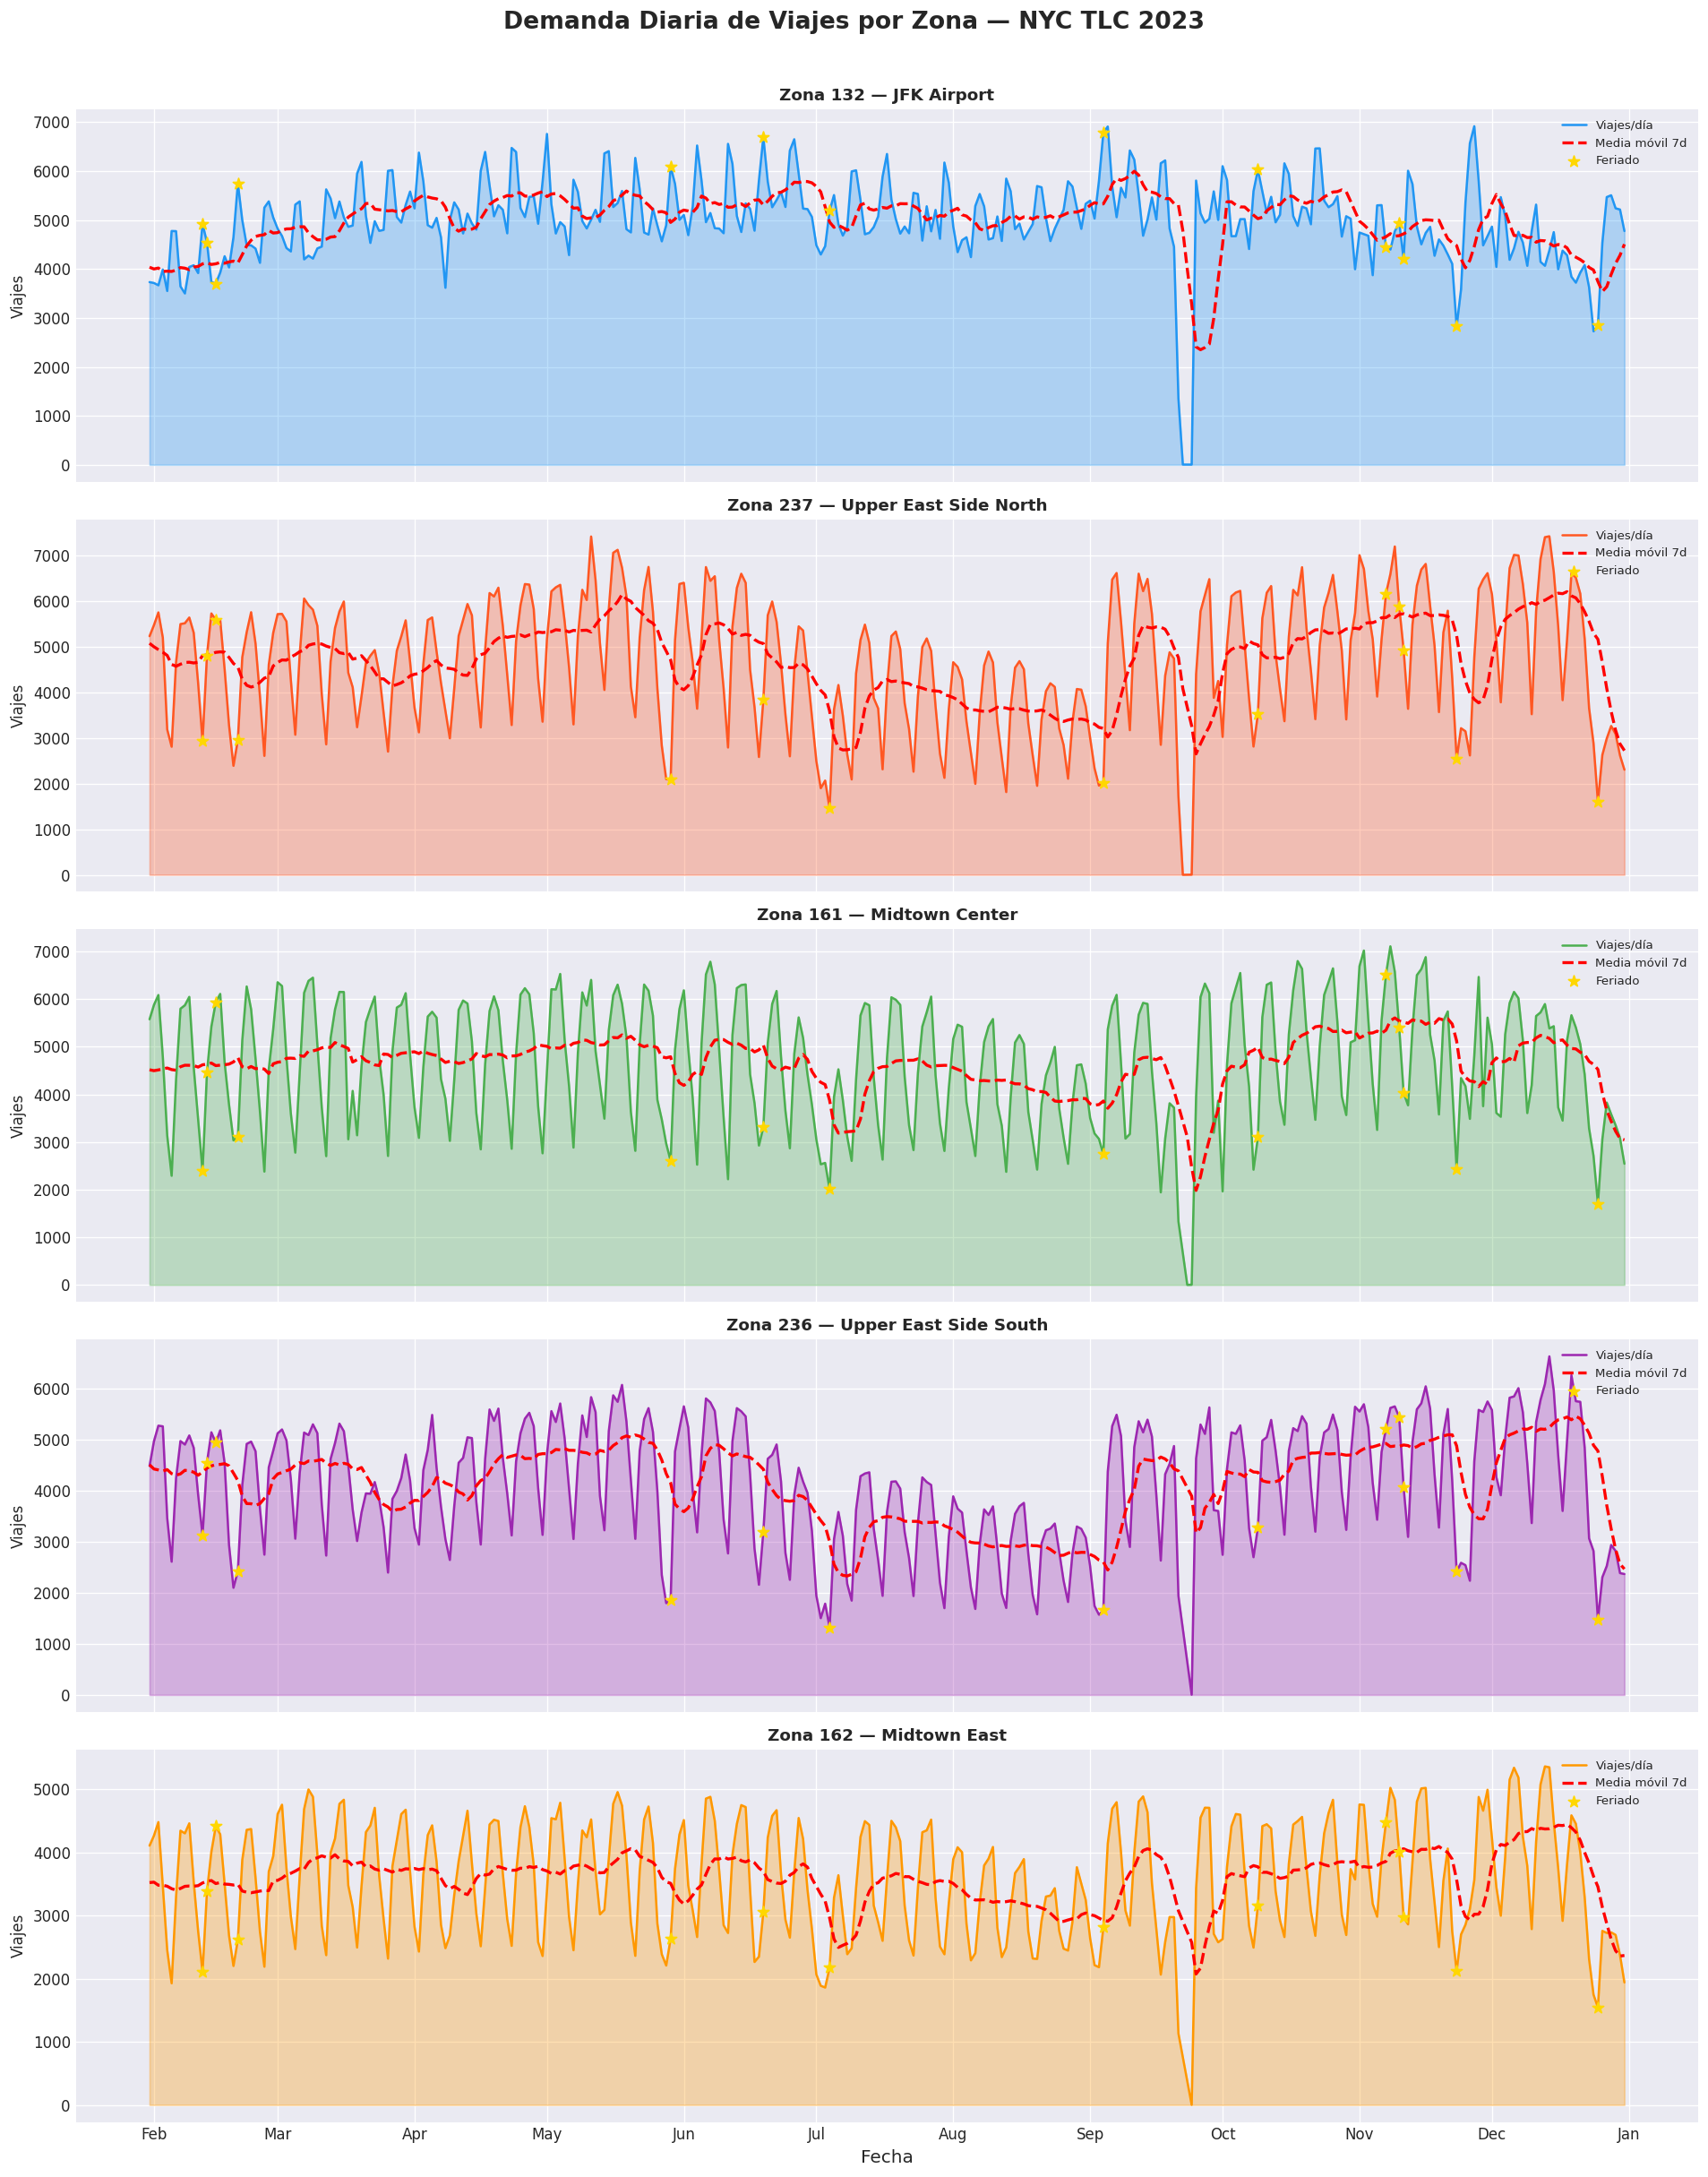

📊 Gráfica guardada: 01_series_tiempo.png


In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1  VISUALIZACIÓN GENERAL — Series de tiempo por zona
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(TOP_N_ZONES, 1, figsize=(16, 4*TOP_N_ZONES), sharex=True)
fig.suptitle('Demanda Diaria de Viajes por Zona — NYC TLC 2023', fontsize=16, fontweight='bold', y=1.01)

for i, (zone_id, ax) in enumerate(zip(top_zones, axes)):
    zone_data = daily[daily['PULocationID'] == zone_id].set_index('pickup_date')
    zone_name = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')

    ax.fill_between(zone_data.index, zone_data['trips'], alpha=0.3, color=PALETTE[i])
    ax.plot(zone_data.index, zone_data['trips'], color=PALETTE[i], linewidth=1.5, label='Viajes/día')
    ax.plot(zone_data.index, zone_data['rolling_7_mean'], color='red',
            linewidth=2, linestyle='--', label='Media móvil 7d')

    # Marcar feriados
    hol = zone_data[zone_data['holiday_flag'] == 1]
    ax.scatter(hol.index, hol['trips'], color='gold', zorder=5, s=60, label='Feriado', marker='*')

    ax.set_ylabel('Viajes', fontsize=10)
    ax.set_title(f'Zona {zone_id} — {zone_name}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xlabel('Fecha', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_series_tiempo.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Gráfica guardada: 01_series_tiempo.png')

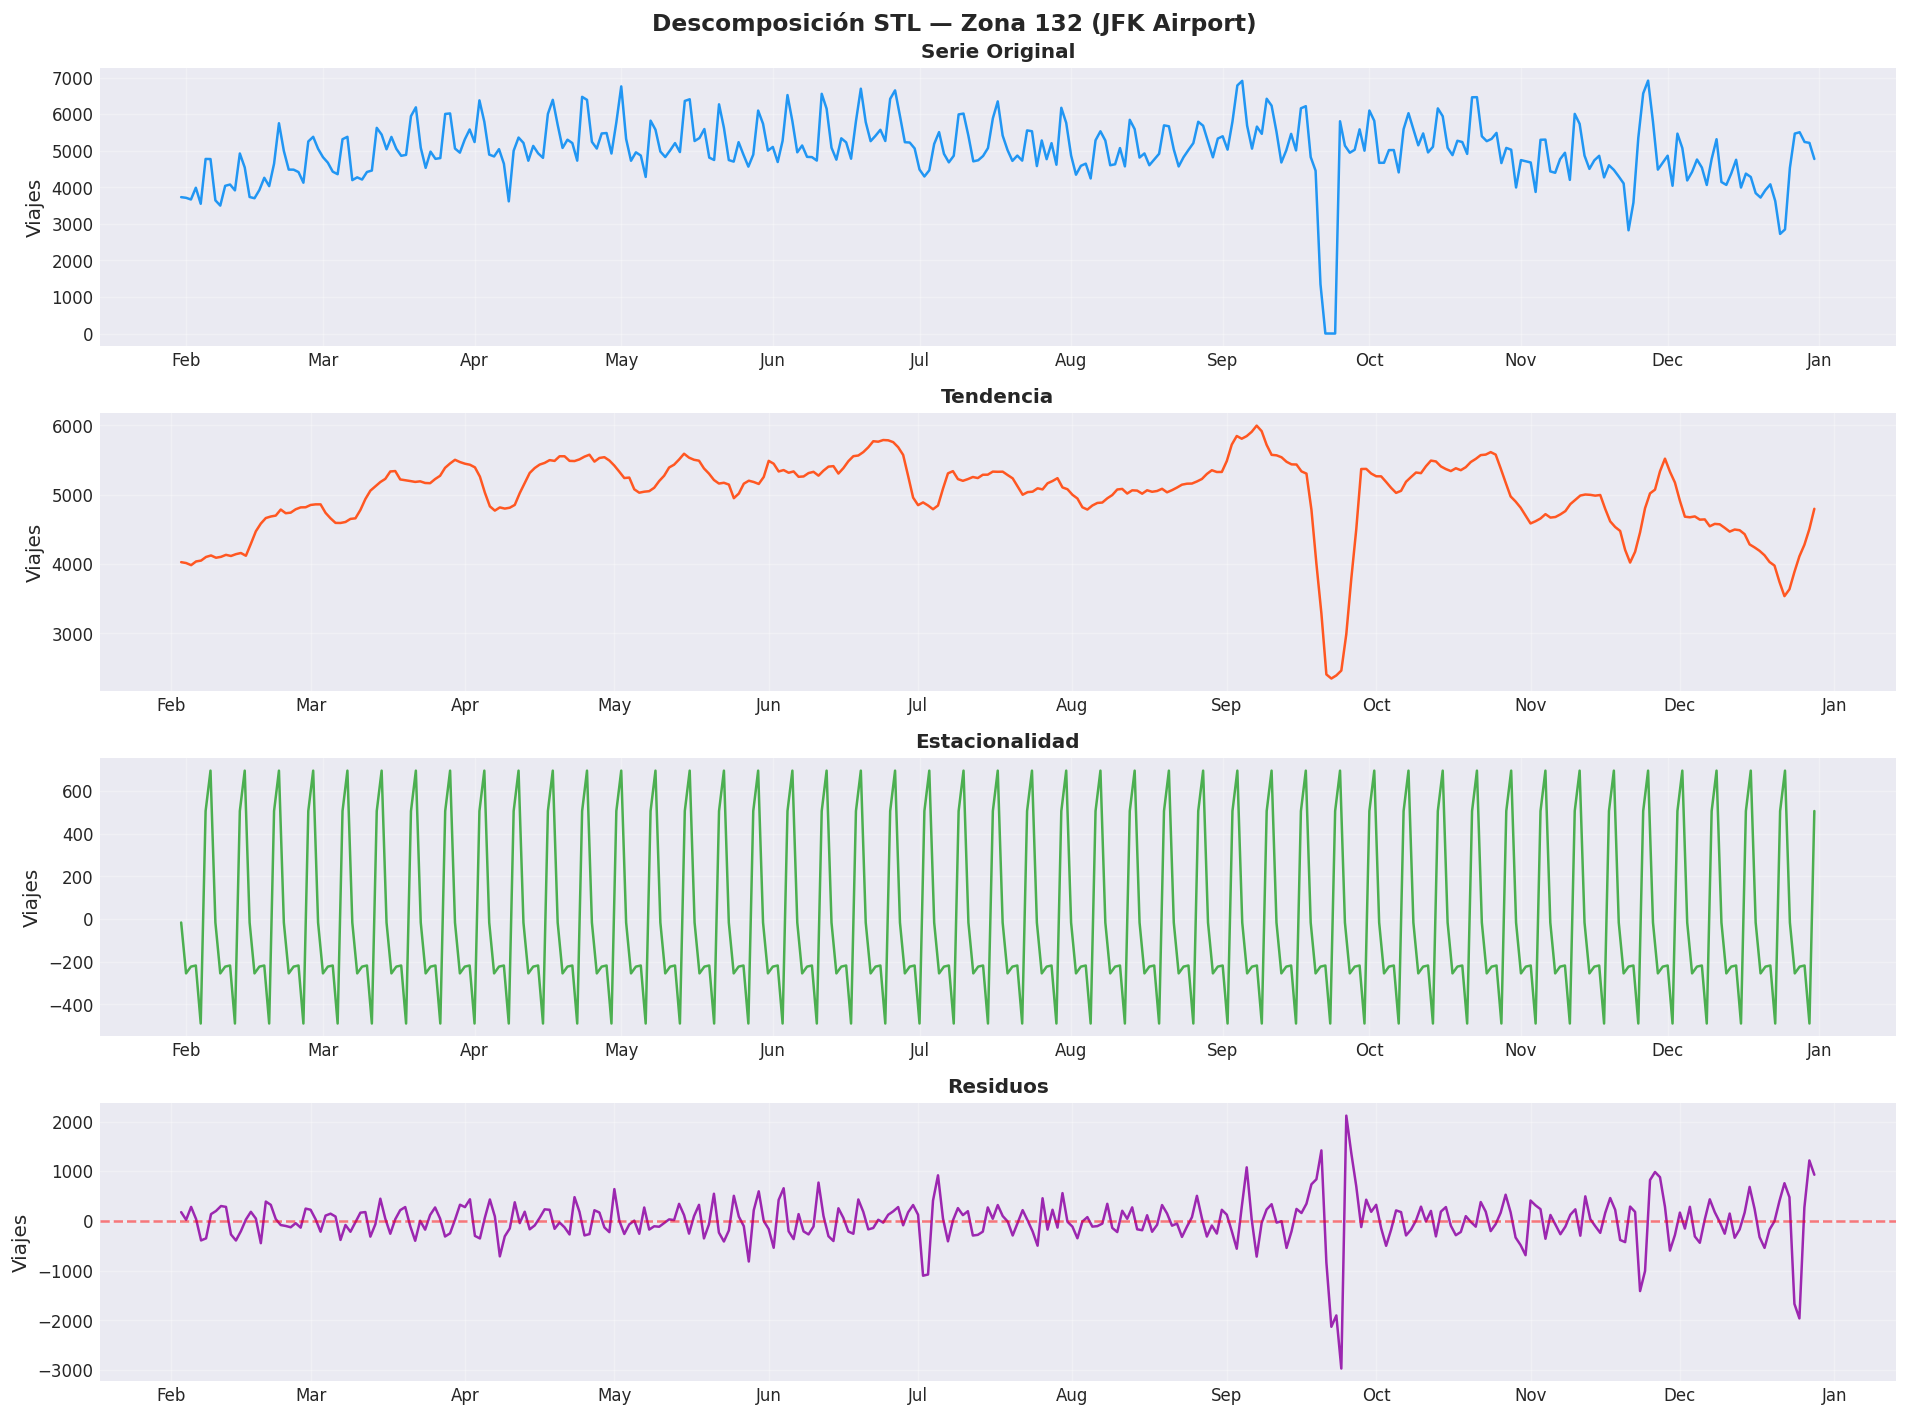

In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.2  DESCOMPOSICIÓN STL — Zona principal
# ══════════════════════════════════════════════════════════════════════════════

PRIMARY_ZONE = top_zones[0]
zone_ts = (
    daily[daily['PULocationID'] == PRIMARY_ZONE]
    .set_index('pickup_date')['trips']
    .asfreq('D')
    .ffill()
)

decomp = seasonal_decompose(zone_ts, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle(f'Descomposición STL — Zona {PRIMARY_ZONE} ({ZONE_NAMES.get(PRIMARY_ZONE, "")})',
             fontsize=14, fontweight='bold')

components = [
    (zone_ts,            'Serie Original',  PALETTE[0]),
    (decomp.trend,       'Tendencia',       PALETTE[1]),
    (decomp.seasonal,    'Estacionalidad',  PALETTE[2]),
    (decomp.resid,       'Residuos',        PALETTE[3]),
]

for ax, (series, title, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Viajes')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)
    if title == 'Residuos':
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_descomposicion_stl.png', bbox_inches='tight', dpi=150)
plt.show()

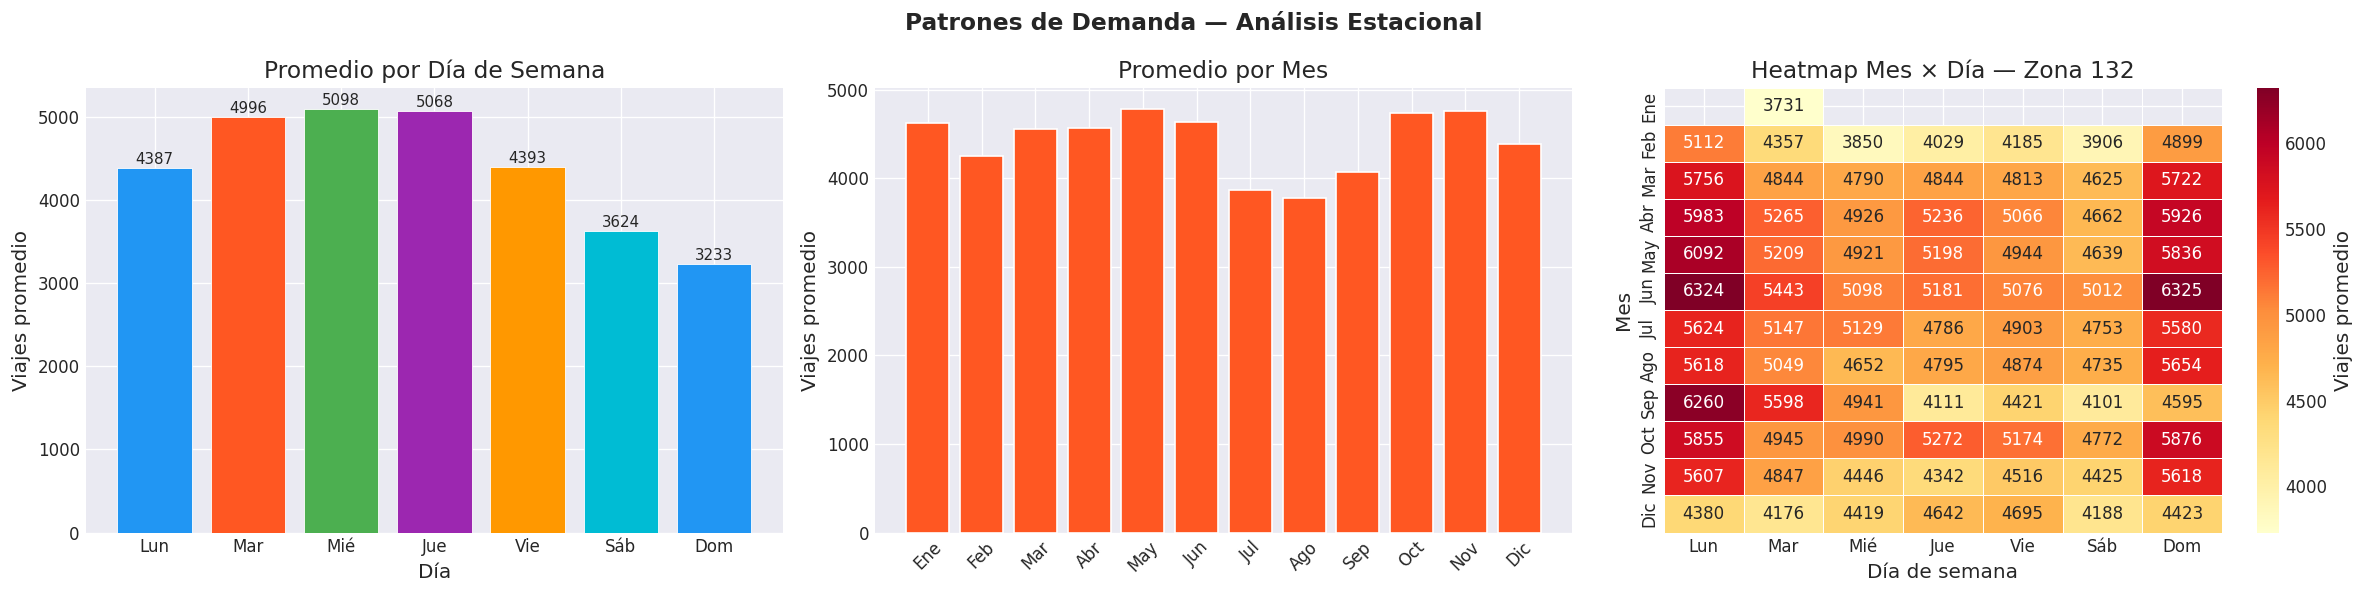

In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.3  PATRONES DE DEMANDA — Heatmaps y distribuciones
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Patrones de Demanda — Análisis Estacional', fontsize=14, fontweight='bold')

# Demanda por día de semana
dow_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
dow_avg = daily.groupby('dow')['trips'].mean()
axes[0].bar(dow_labels, dow_avg.values, color=PALETTE[:7], edgecolor='white', linewidth=0.5)
axes[0].set_title('Promedio por Día de Semana')
axes[0].set_ylabel('Viajes promedio')
axes[0].set_xlabel('Día')
for i, v in enumerate(dow_avg.values):
    axes[0].text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

# Demanda por mes
month_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
month_avg = daily.groupby('month')['trips'].mean()
axes[1].bar(range(1,13), month_avg.values, color=PALETTE[1], edgecolor='white')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_labels, rotation=45)
axes[1].set_title('Promedio por Mes')
axes[1].set_ylabel('Viajes promedio')

# Heatmap: Mes × Día de semana (zona principal)
z0 = daily[daily['PULocationID'] == PRIMARY_ZONE]
heat = z0.groupby(['month', 'dow'])['trips'].mean().unstack()
heat.columns = dow_labels
heat.index   = [month_labels[m-1] for m in heat.index]
sns.heatmap(heat, ax=axes[2], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Viajes promedio'})
axes[2].set_title(f'Heatmap Mes × Día — Zona {PRIMARY_ZONE}')
axes[2].set_xlabel('Día de semana')
axes[2].set_ylabel('Mes')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_patrones_demanda.png', bbox_inches='tight', dpi=150)
plt.show()

In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.4  TEST DE ESTACIONARIEDAD (Dickey-Fuller)
# ══════════════════════════════════════════════════════════════════════════════

print('=== Prueba Dickey-Fuller Aumentada (ADF) por Zona ===')
print(f'{"Zona":<35} {"ADF Stat":>10} {"p-value":>10} {"Estacionaria":>14}')
print('─' * 75)

for zone_id in top_zones:
    ts = daily[daily['PULocationID'] == zone_id]['trips'].values
    result = adfuller(ts, autolag='AIC')
    adf_stat, p_value = result[0], result[1]
    is_stationary = '✅ Sí' if p_value < 0.05 else '❌ No'
    name = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    print(f'Zona {zone_id} ({name[:25]:<25}) {adf_stat:>10.4f} {p_value:>10.4f} {is_stationary:>14}')

=== Prueba Dickey-Fuller Aumentada (ADF) por Zona ===
Zona                                  ADF Stat    p-value   Estacionaria
───────────────────────────────────────────────────────────────────────────
Zona 132 (JFK Airport              )    -4.0849     0.0010           ✅ Sí
Zona 237 (Upper East Side North    )    -3.0343     0.0318           ✅ Sí
Zona 161 (Midtown Center           )    -3.1471     0.0233           ✅ Sí
Zona 236 (Upper East Side South    )    -2.5420     0.1056           ❌ No
Zona 162 (Midtown East             )    -3.9942     0.0014           ✅ Sí


## 5. Modelo Base — Regresión Lineal <a id='5'></a>
> Baseline siguiendo metodología de [GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/transport-demand-prediction-using-regression/)

In [51]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.1  PREPARACIÓN DE FEATURES PARA MODELOS ML
# ══════════════════════════════════════════════════════════════════════════════

FEATURE_COLS = [
    'dow', 'month', 'week', 'day_of_year',
    'holiday_flag', 'weekend_flag',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std', 'rolling_14_mean', 'rolling_30_mean',
    'avg_distance', 'avg_fare', 'avg_duration',
]
TARGET_COL = 'trips'

# División temporal: 80% train / 20% test
# IMPORTANTE: en series de tiempo NO se mezclan períodos
def temporal_split(df_zone, test_ratio=0.2):
    n = len(df_zone)
    split_idx = int(n * (1 - test_ratio))
    train = df_zone.iloc[:split_idx].copy()
    test  = df_zone.iloc[split_idx:].copy()
    return train, test

# Métricas
def compute_metrics(y_true, y_pred, model_name=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

# Almacén de resultados
all_results = []
predictions_store = {}  # {(zone_id, model_name): {test_dates, y_true, y_pred}}

print('✅ Configuración de modelos ML lista')
print(f'Features: {FEATURE_COLS}')

✅ Configuración de modelos ML lista
Features: ['dow', 'month', 'week', 'day_of_year', 'holiday_flag', 'weekend_flag', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7_mean', 'rolling_7_std', 'rolling_14_mean', 'rolling_30_mean', 'avg_distance', 'avg_fare', 'avg_duration']


In [52]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.2  ENTRENAMIENTO — Regresión Lineal (Baseline)
# ══════════════════════════════════════════════════════════════════════════════

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  MODELO BASE: Regresión Lineal (Ridge)')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

lr_models = {}

for zone_id in top_zones:
    zone_data = daily[daily['PULocationID'] == zone_id].sort_values('pickup_date').copy()
    train, test = temporal_split(zone_data)

    X_train = train[FEATURE_COLS]
    y_train = train[TARGET_COL]
    X_test  = test[FEATURE_COLS]
    y_test  = test[TARGET_COL]

    # Pipeline con escalado
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_pred = np.maximum(y_pred, 0)  # no puede haber viajes negativos

    metrics = compute_metrics(y_test.values, y_pred, 'LinearRegression')
    metrics['zone_id'] = zone_id
    metrics['zone_name'] = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    all_results.append(metrics)
    lr_models[zone_id] = pipe
    predictions_store[(zone_id, 'LinearRegression')] = {
        'dates': test['pickup_date'].values,
        'y_true': y_test.values,
        'y_pred': y_pred
    }

    name = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    print(f'  Zona {zone_id} ({name[:30]:<30}) RMSE={metrics["RMSE"]:8.1f} | MAE={metrics["MAE"]:7.1f} | R²={metrics["R2"]:6.3f}')

print('✅ Regresión Lineal completada')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODELO BASE: Regresión Lineal (Ridge)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Zona 132 (JFK Airport                   ) RMSE=   902.1 | MAE=  748.0 | R²=-0.408
  Zona 237 (Upper East Side North         ) RMSE=   624.8 | MAE=  495.5 | R²= 0.830
  Zona 161 (Midtown Center                ) RMSE=   847.6 | MAE=  657.9 | R²= 0.557
  Zona 236 (Upper East Side South         ) RMSE=   510.1 | MAE=  398.0 | R²= 0.844
  Zona 162 (Midtown East                  ) RMSE=   493.2 | MAE=  388.4 | R²= 0.751
✅ Regresión Lineal completada


## 6. Modelos de Ensamble — Random Forest & XGBoost <a id='6'></a>

In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.1  RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  MODELO 2: Random Forest Regressor')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

rf_models = {}

for zone_id in top_zones:
    zone_data = daily[daily['PULocationID'] == zone_id].sort_values('pickup_date').copy()
    train, test = temporal_split(zone_data)

    X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
    X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

    rf = RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=3,
        max_features='sqrt', n_jobs=-1, random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_pred = np.maximum(y_pred, 0)

    metrics = compute_metrics(y_test.values, y_pred, 'RandomForest')
    metrics['zone_id']   = zone_id
    metrics['zone_name'] = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    all_results.append(metrics)
    rf_models[zone_id] = rf
    predictions_store[(zone_id, 'RandomForest')] = {
        'dates': test['pickup_date'].values,
        'y_true': y_test.values,
        'y_pred': y_pred
    }

    name = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    print(f'  Zona {zone_id} ({name[:30]:<30}) RMSE={metrics["RMSE"]:8.1f} | MAE={metrics["MAE"]:7.1f} | R²={metrics["R2"]:6.3f}')

print('✅ Random Forest completado')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODELO 2: Random Forest Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Zona 132 (JFK Airport                   ) RMSE=   648.6 | MAE=  543.8 | R²= 0.272
  Zona 237 (Upper East Side North         ) RMSE=   815.9 | MAE=  615.2 | R²= 0.711
  Zona 161 (Midtown Center                ) RMSE=   815.7 | MAE=  610.1 | R²= 0.590
  Zona 236 (Upper East Side South         ) RMSE=   693.2 | MAE=  534.9 | R²= 0.712
  Zona 162 (Midtown East                  ) RMSE=   620.0 | MAE=  498.4 | R²= 0.606
✅ Random Forest completado


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.2  XGBOOST
# ══════════════════════════════════════════════════════════════════════════════

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  MODELO 3: XGBoost Regressor')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

xgb_models = {}

for zone_id in top_zones:
    zone_data = daily[daily['PULocationID'] == zone_id].sort_values('pickup_date').copy()
    train, test = temporal_split(zone_data)

    X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
    X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

    model = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        early_stopping_rounds=50, eval_metric='rmse',
        random_state=42, n_jobs=-1, verbosity=0
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    y_pred = model.predict(X_test)
    y_pred = np.maximum(y_pred, 0)

    metrics = compute_metrics(y_test.values, y_pred, 'XGBoost')
    metrics['zone_id']   = zone_id
    metrics['zone_name'] = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    all_results.append(metrics)
    xgb_models[zone_id] = model
    predictions_store[(zone_id, 'XGBoost')] = {
        'dates': test['pickup_date'].values,
        'y_true': y_test.values,
        'y_pred': y_pred
    }

    name = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    print(f'  Zona {zone_id} ({name[:30]:<30}) RMSE={metrics["RMSE"]:8.1f} | MAE={metrics["MAE"]:7.1f} | R²={metrics["R2"]:6.3f}')

print('✅ XGBoost completado')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODELO 3: XGBoost Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Zona 132 (JFK Airport                   ) RMSE=   663.9 | MAE=  536.8 | R²= 0.238
  Zona 237 (Upper East Side North         ) RMSE=   898.4 | MAE=  716.9 | R²= 0.649
  Zona 161 (Midtown Center                ) RMSE=   756.5 | MAE=  584.2 | R²= 0.647
  Zona 236 (Upper East Side South         ) RMSE=   626.5 | MAE=  471.5 | R²= 0.765
  Zona 162 (Midtown East                  ) RMSE=   534.8 | MAE=  421.5 | R²= 0.707
✅ XGBoost completado


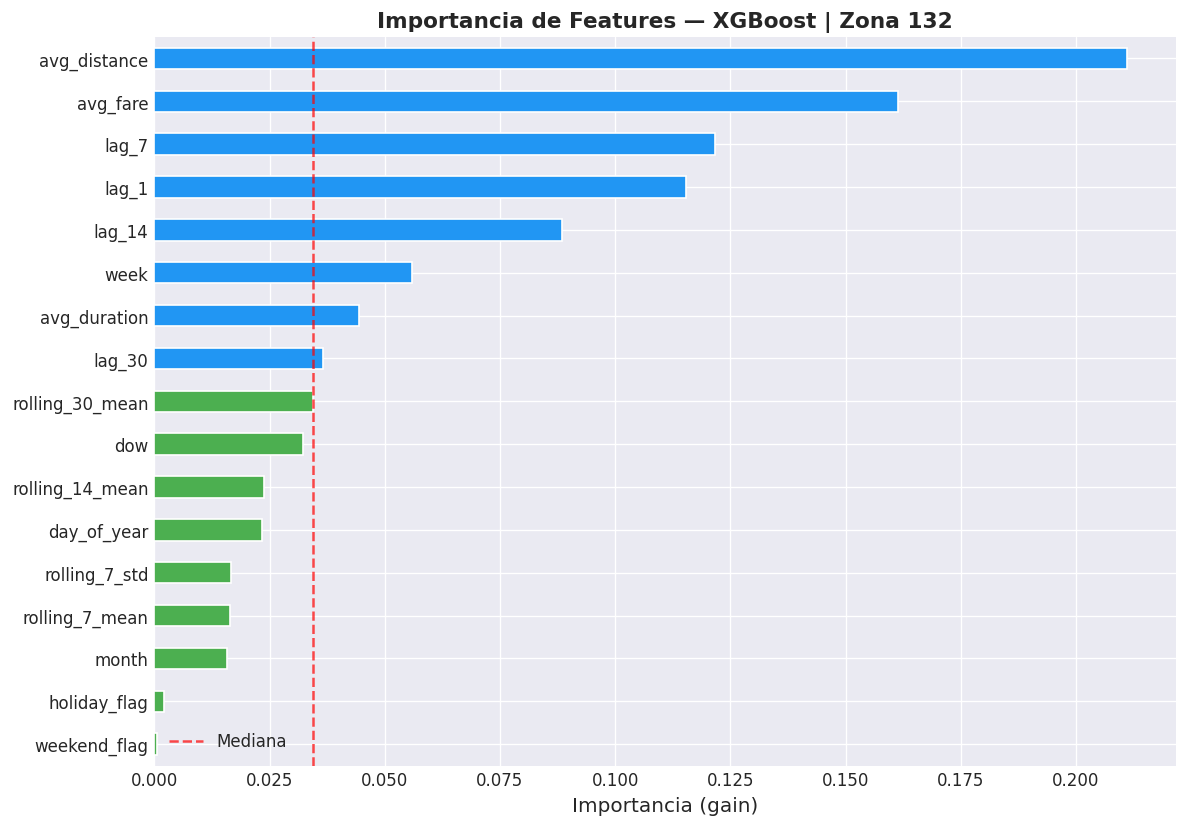

In [55]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.3  IMPORTANCIA DE FEATURES — XGBoost (zona principal)
# ══════════════════════════════════════════════════════════════════════════════

fi = pd.Series(
    xgb_models[PRIMARY_ZONE].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[0] if v > fi.median() else PALETTE[2] for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title(f'Importancia de Features — XGBoost | Zona {PRIMARY_ZONE}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (gain)')
ax.axvline(fi.median(), color='red', linestyle='--', alpha=0.7, label='Mediana')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Modelo de Deep Learning — LSTM <a id='7'></a>

In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.1  PREPARACIÓN DE SECUENCIAS PARA LSTM
# ══════════════════════════════════════════════════════════════════════════════

SEQ_LEN = 30  # ventana de 30 días para predecir el día siguiente

def create_sequences(data, seq_len=30, features=None, target='trips'):
    """Convierte serie temporal en secuencias (X, y) para LSTM."""
    if features is None:
        features = [target]
    X, y = [], []
    values = data[features].values
    targets = data[target].values
    for i in range(len(data) - seq_len):
        X.append(values[i:i+seq_len])
        y.append(targets[i+seq_len])
    return np.array(X), np.array(y)

# Features para LSTM (multivariado)
LSTM_FEATURES = ['trips', 'dow', 'month', 'weekend_flag', 'holiday_flag',
                 'avg_distance', 'avg_fare', 'rolling_7_mean']

print('✅ Función create_sequences definida')
print(f'   Longitud de secuencia: {SEQ_LEN} días')
print(f'   Features LSTM: {LSTM_FEATURES}')

✅ Función create_sequences definida
   Longitud de secuencia: 30 días
   Features LSTM: ['trips', 'dow', 'month', 'weekend_flag', 'holiday_flag', 'avg_distance', 'avg_fare', 'rolling_7_mean']


In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.2  ARQUITECTURA DEL MODELO LSTM
# ══════════════════════════════════════════════════════════════════════════════

def build_lstm_model(seq_len, n_features, units=128):
    """
    Arquitectura Bidirectional LSTM + Dropout + Dense
    Inspirada en enfoques de demanda de transporte urbano.
    """
    model = Sequential([
        # Primera capa LSTM bidireccional
        Bidirectional(
            LSTM(units, return_sequences=True, activation='tanh'),
            input_shape=(seq_len, n_features)
        ),
        BatchNormalization(),
        Dropout(0.2),

        # Segunda capa LSTM
        LSTM(units // 2, return_sequences=True, activation='tanh'),
        BatchNormalization(),
        Dropout(0.2),

        # Tercera capa LSTM
        LSTM(units // 4, return_sequences=False, activation='tanh'),
        Dropout(0.1),

        # Capas densas
        Dense(64, activation='relu'),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Salida continua: nº de viajes
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='huber',          # Robusto a outliers
        metrics=['mae']
    )
    return model

# Mostrar arquitectura (zona principal)
sample_model = build_lstm_model(SEQ_LEN, len(LSTM_FEATURES))
sample_model.summary()
del sample_model

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 30, 256)        │       140,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 30, 64)         │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,385 (939.00 KB)

 Trainable params: 239,745 (936.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [58]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.3  ENTRENAMIENTO LSTM POR ZONA
# ══════════════════════════════════════════════════════════════════════════════

lstm_models   = {}
lstm_scalers  = {}
LSTM_EPOCHS   = 80
LSTM_BATCH    = 32

for zone_id in top_zones:
    print(f'\n🔧 Entrenando LSTM — Zona {zone_id} ({ZONE_NAMES.get(zone_id, "")})...')

    zone_data = daily[daily['PULocationID'] == zone_id].sort_values('pickup_date').copy()

    # Escalar features
    scaler = MinMaxScaler()
    zone_data[LSTM_FEATURES] = scaler.fit_transform(zone_data[LSTM_FEATURES])
    lstm_scalers[zone_id] = scaler

    # Crear secuencias
    X, y = create_sequences(zone_data, seq_len=SEQ_LEN, features=LSTM_FEATURES)

    # Split temporal
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Obtener fechas del set de test
    test_dates = zone_data['pickup_date'].values[split + SEQ_LEN:]

    # Callbacks
    callbacks = [
        EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-6, monitor='val_loss'),
        ModelCheckpoint(
            filepath=str(MODELS_DIR / f'lstm/lstm_zone_{zone_id}.keras'),
            save_best_only=True, monitor='val_loss'
        )
    ]

    # Modelo
    model = build_lstm_model(SEQ_LEN, len(LSTM_FEATURES))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH,
        callbacks=callbacks,
        verbose=0
    )

    # Predicción (escala normalizada)
    y_pred_norm = model.predict(X_test, verbose=0).flatten()

    # Desnormalizar: reconstruir array completo y extraer la columna 'trips'
    trips_col_idx = LSTM_FEATURES.index('trips')
    n_feat = len(LSTM_FEATURES)

    def inverse_trips(arr_norm, scaler, idx, n_features):
        dummy = np.zeros((len(arr_norm), n_features))
        dummy[:, idx] = arr_norm
        return scaler.inverse_transform(dummy)[:, idx]

    y_true_real = inverse_trips(y_test, scaler, trips_col_idx, n_feat)
    y_pred_real = inverse_trips(y_pred_norm, scaler, trips_col_idx, n_feat)
    y_pred_real = np.maximum(y_pred_real, 0)

    metrics = compute_metrics(y_true_real, y_pred_real, 'LSTM')
    metrics['zone_id']   = zone_id
    metrics['zone_name'] = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    all_results.append(metrics)
    lstm_models[zone_id] = (model, history)
    predictions_store[(zone_id, 'LSTM')] = {
        'dates': test_dates,
        'y_true': y_true_real,
        'y_pred': y_pred_real
    }

    stopped_epoch = len(history.history['loss'])
    print(f'  → Épocas: {stopped_epoch}/{LSTM_EPOCHS} | RMSE={metrics["RMSE"]:8.1f} | MAE={metrics["MAE"]:7.1f} | R²={metrics["R2"]:6.3f}')

print('\n✅ Entrenamiento LSTM completado para todas las zonas')


🔧 Entrenando LSTM — Zona 132 (JFK Airport)...
  → Épocas: 45/80 | RMSE=   766.2 | MAE=  576.8 | R²= 0.025

🔧 Entrenando LSTM — Zona 237 (Upper East Side North)...
  → Épocas: 27/80 | RMSE=  1779.4 | MAE= 1606.2 | R²=-0.303

🔧 Entrenando LSTM — Zona 161 (Midtown Center)...
  → Épocas: 67/80 | RMSE=  1068.5 | MAE=  874.2 | R²= 0.319

🔧 Entrenando LSTM — Zona 236 (Upper East Side South)...
  → Épocas: 21/80 | RMSE=  2447.5 | MAE= 2119.2 | R²=-2.412

🔧 Entrenando LSTM — Zona 162 (Midtown East)...
  → Épocas: 80/80 | RMSE=   753.1 | MAE=  627.6 | R²= 0.447

✅ Entrenamiento LSTM completado para todas las zonas


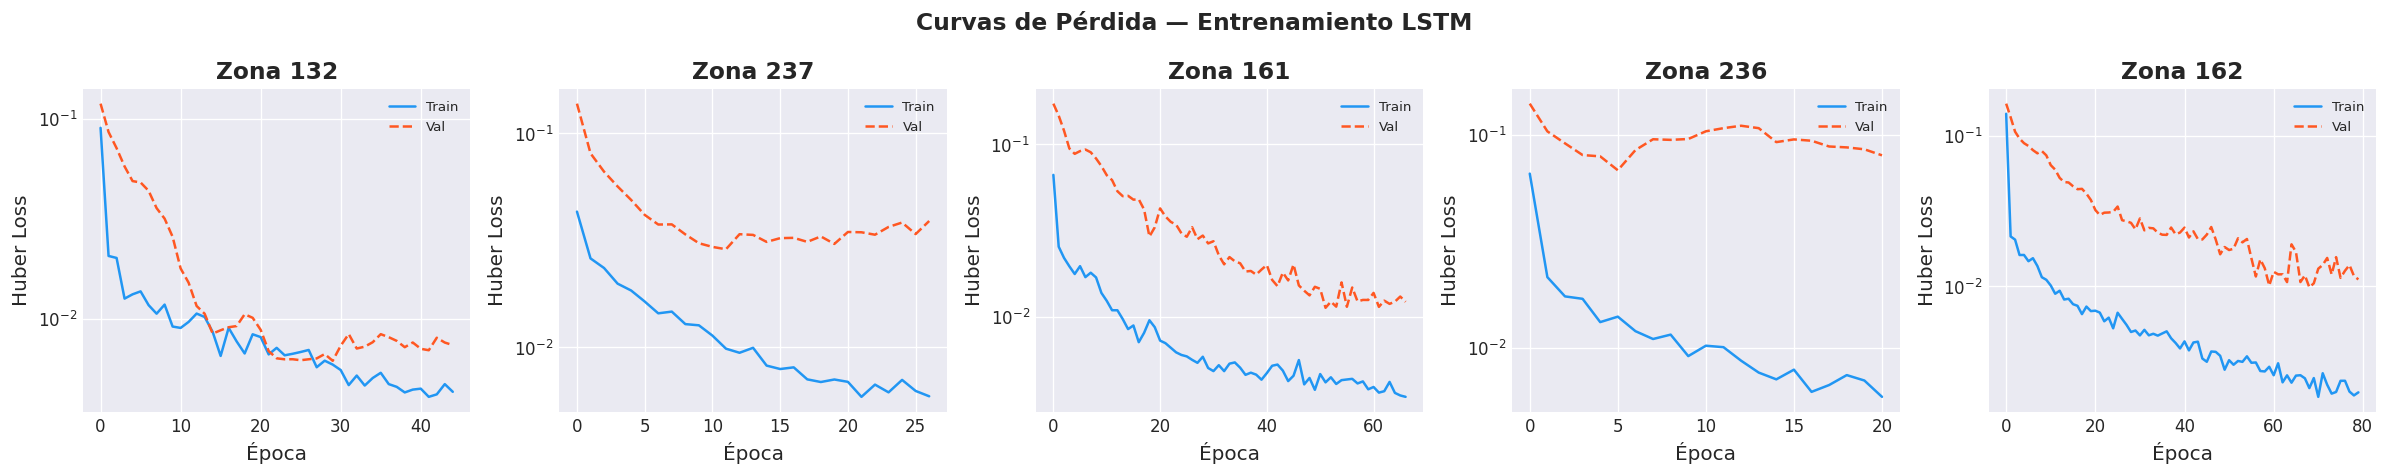

In [59]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.4  CURVAS DE ENTRENAMIENTO LSTM
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, TOP_N_ZONES, figsize=(20, 4))
fig.suptitle('Curvas de Pérdida — Entrenamiento LSTM', fontsize=14, fontweight='bold')

for ax, zone_id in zip(axes, top_zones):
    _, hist = lstm_models[zone_id]
    ax.plot(hist.history['loss'],     label='Train', color=PALETTE[0])
    ax.plot(hist.history['val_loss'], label='Val',   color=PALETTE[1], linestyle='--')
    ax.set_title(f'Zona {zone_id}', fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Huber Loss')
    ax.legend(fontsize=8)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_lstm_training.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Modelo Prophet (Series de Tiempo) <a id='8'></a>

In [60]:
# ══════════════════════════════════════════════════════════════════════════════
# 8.1  ENTRENAMIENTO PROPHET
# ══════════════════════════════════════════════════════════════════════════════

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  MODELO 4: Prophet (Meta)')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

prophet_models = {}

for zone_id in top_zones:
    zone_data = (
        daily[daily['PULocationID'] == zone_id]
        .sort_values('pickup_date')
        [['pickup_date', 'trips', 'holiday_flag']]
        .rename(columns={'pickup_date': 'ds', 'trips': 'y', 'holiday_flag': 'is_holiday'})
    )
    
    # Split
    split = int(len(zone_data) * 0.8)
    train_p = zone_data.iloc[:split]
    test_p  = zone_data.iloc[split:]
    
    # Feriados
    holiday_df = zone_data[zone_data['is_holiday'] == 1][['ds']].copy()
    holiday_df['holiday'] = 'US_Holiday'
    holiday_df['lower_window'] = -1
    holiday_df['upper_window'] = 1
    
    # Modelo Prophet
    m = Prophet(
        seasonality_mode='multiplicative',
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
        holidays=holiday_df,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        interval_width=0.95
    )
    m.fit(train_p[['ds', 'y']])
    
    # Predicción
    future   = m.make_future_dataframe(periods=len(test_p), freq='D')
    forecast = m.predict(future)
    
    # Comparar con test
    pred_test = forecast.tail(len(test_p))['yhat'].values
    pred_test = np.maximum(pred_test, 0)
    y_true_p  = test_p['y'].values
    
    metrics = compute_metrics(y_true_p, pred_test, 'Prophet')
    metrics['zone_id']   = zone_id
    metrics['zone_name'] = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    all_results.append(metrics)
    prophet_models[zone_id] = (m, forecast)
    predictions_store[(zone_id, 'Prophet')] = {
        'dates': test_p['ds'].values,
        'y_true': y_true_p,
        'y_pred': pred_test
    }
    
    name = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    print(f'  Zona {zone_id} ({name[:30]:<30}) RMSE={metrics["RMSE"]:8.1f} | MAE={metrics["MAE"]:7.1f} | R²={metrics["R2"]:6.3f}')

print('✅ Prophet completado')

21:15:56 - cmdstanpy - INFO - Chain [1] start processing


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODELO 4: Prophet (Meta)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


21:15:56 - cmdstanpy - INFO - Chain [1] done processing
21:15:56 - cmdstanpy - INFO - Chain [1] start processing
21:15:56 - cmdstanpy - INFO - Chain [1] done processing


  Zona 132 (JFK Airport                   ) RMSE=  1682.6 | MAE= 1357.2 | R²=-3.897


21:15:56 - cmdstanpy - INFO - Chain [1] start processing
21:15:56 - cmdstanpy - INFO - Chain [1] done processing


  Zona 237 (Upper East Side North         ) RMSE=  1620.5 | MAE= 1166.2 | R²=-0.142


21:15:57 - cmdstanpy - INFO - Chain [1] start processing
21:15:57 - cmdstanpy - INFO - Chain [1] done processing


  Zona 161 (Midtown Center                ) RMSE=  1532.4 | MAE= 1180.3 | R²=-0.448


21:15:57 - cmdstanpy - INFO - Chain [1] start processing
21:15:57 - cmdstanpy - INFO - Chain [1] done processing


  Zona 236 (Upper East Side South         ) RMSE=  1958.4 | MAE= 1697.1 | R²=-1.301
  Zona 162 (Midtown East                  ) RMSE=  1028.5 | MAE=  788.1 | R²=-0.083
✅ Prophet completado


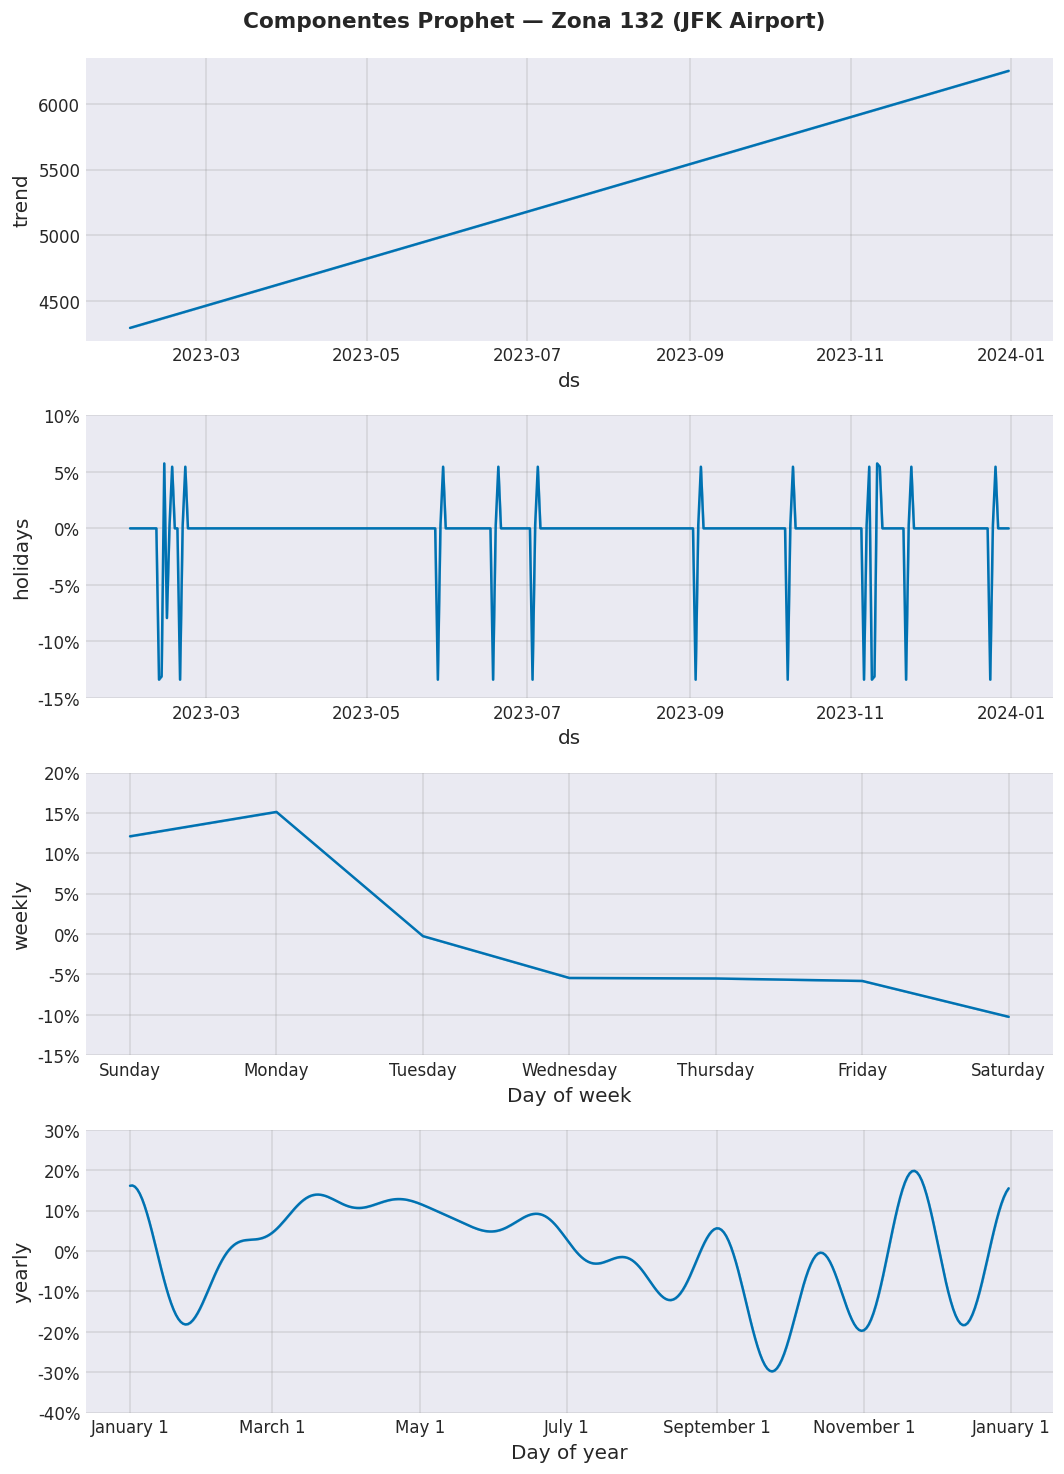

In [61]:
# ══════════════════════════════════════════════════════════════════════════════
# 8.2  COMPONENTES PROPHET — Zona principal
# ══════════════════════════════════════════════════════════════════════════════

m_main, forecast_main = prophet_models[PRIMARY_ZONE]
fig = m_main.plot_components(forecast_main)
fig.suptitle(f'Componentes Prophet — Zona {PRIMARY_ZONE} ({ZONE_NAMES.get(PRIMARY_ZONE, "")})',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f'{OUTPUT_DIR}/06_prophet_components.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Comparación de Modelos y Métricas <a id='9'></a>

In [62]:
# ══════════════════════════════════════════════════════════════════════════════
# 9.1  TABLA COMPARATIVA DE MÉTRICAS
# ══════════════════════════════════════════════════════════════════════════════

results_df = pd.DataFrame(all_results)
results_df['RMSE'] = results_df['RMSE'].round(1)
results_df['MAE']  = results_df['MAE'].round(1)
results_df['MAPE'] = results_df['MAPE'].round(2)
results_df['R2']   = results_df['R2'].round(4)

print('\n📊 MÉTRICAS COMPARATIVAS POR MODELO Y ZONA')
print('═' * 90)
display(
    results_df[['model', 'zone_id', 'zone_name', 'RMSE', 'MAE', 'MAPE', 'R2']]
    .sort_values(['zone_id', 'RMSE'])
    .style
    .background_gradient(subset=['RMSE', 'MAE', 'MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .format({'RMSE': '{:.1f}', 'MAE': '{:.1f}', 'MAPE': '{:.2f}%', 'R2': '{:.4f}'})
)

print('\n📊 MÉTRICAS PROMEDIO POR MODELO')
display(
    results_df.groupby('model')[['RMSE', 'MAE', 'MAPE', 'R2']]
    .mean().round(3)
    .sort_values('RMSE')
    .style.background_gradient(subset=['RMSE', 'MAE', 'MAPE'], cmap='RdYlGn_r')
          .background_gradient(subset=['R2'], cmap='RdYlGn')
)


📊 MÉTRICAS COMPARATIVAS POR MODELO Y ZONA
══════════════════════════════════════════════════════════════════════════════════════════


,model,zone_id,zone_name,RMSE,MAE,MAPE,R2
5,RandomForest,132,JFK Airport,648.6,543.8,12.71%,0.2724
10,XGBoost,132,JFK Airport,663.9,536.8,12.44%,0.2376
15,LSTM,132,JFK Airport,766.2,576.8,13.78%,0.0248
0,LinearRegression,132,JFK Airport,902.1,748.0,18.20%,-0.4076
20,Prophet,132,JFK Airport,1682.6,1357.2,32.43%,-3.8971
12,XGBoost,161,Midtown Center,756.5,584.2,13.94%,0.6470
7,RandomForest,161,Midtown Center,815.7,610.1,15.38%,0.5896
2,LinearRegression,161,Midtown Center,847.6,657.9,15.10%,0.5569
17,LSTM,161,Midtown Center,1068.5,874.2,21.00%,0.3189
22,Prophet,161,Midtown Center,1532.4,1180.3,30.21%,-0.4484



📊 MÉTRICAS PROMEDIO POR MODELO


,RMSE,MAE,MAPE,R2
model,,,,
LinearRegression,675.560000,537.560000,13.212000,0.515000
XGBoost,696.020000,546.180000,13.742000,0.601000
RandomForest,718.680000,560.480000,14.856000,0.578000
LSTM,1362.940000,1160.800000,25.720000,-0.385000
Prophet,1564.480000,1237.780000,32.320000,-1.174000


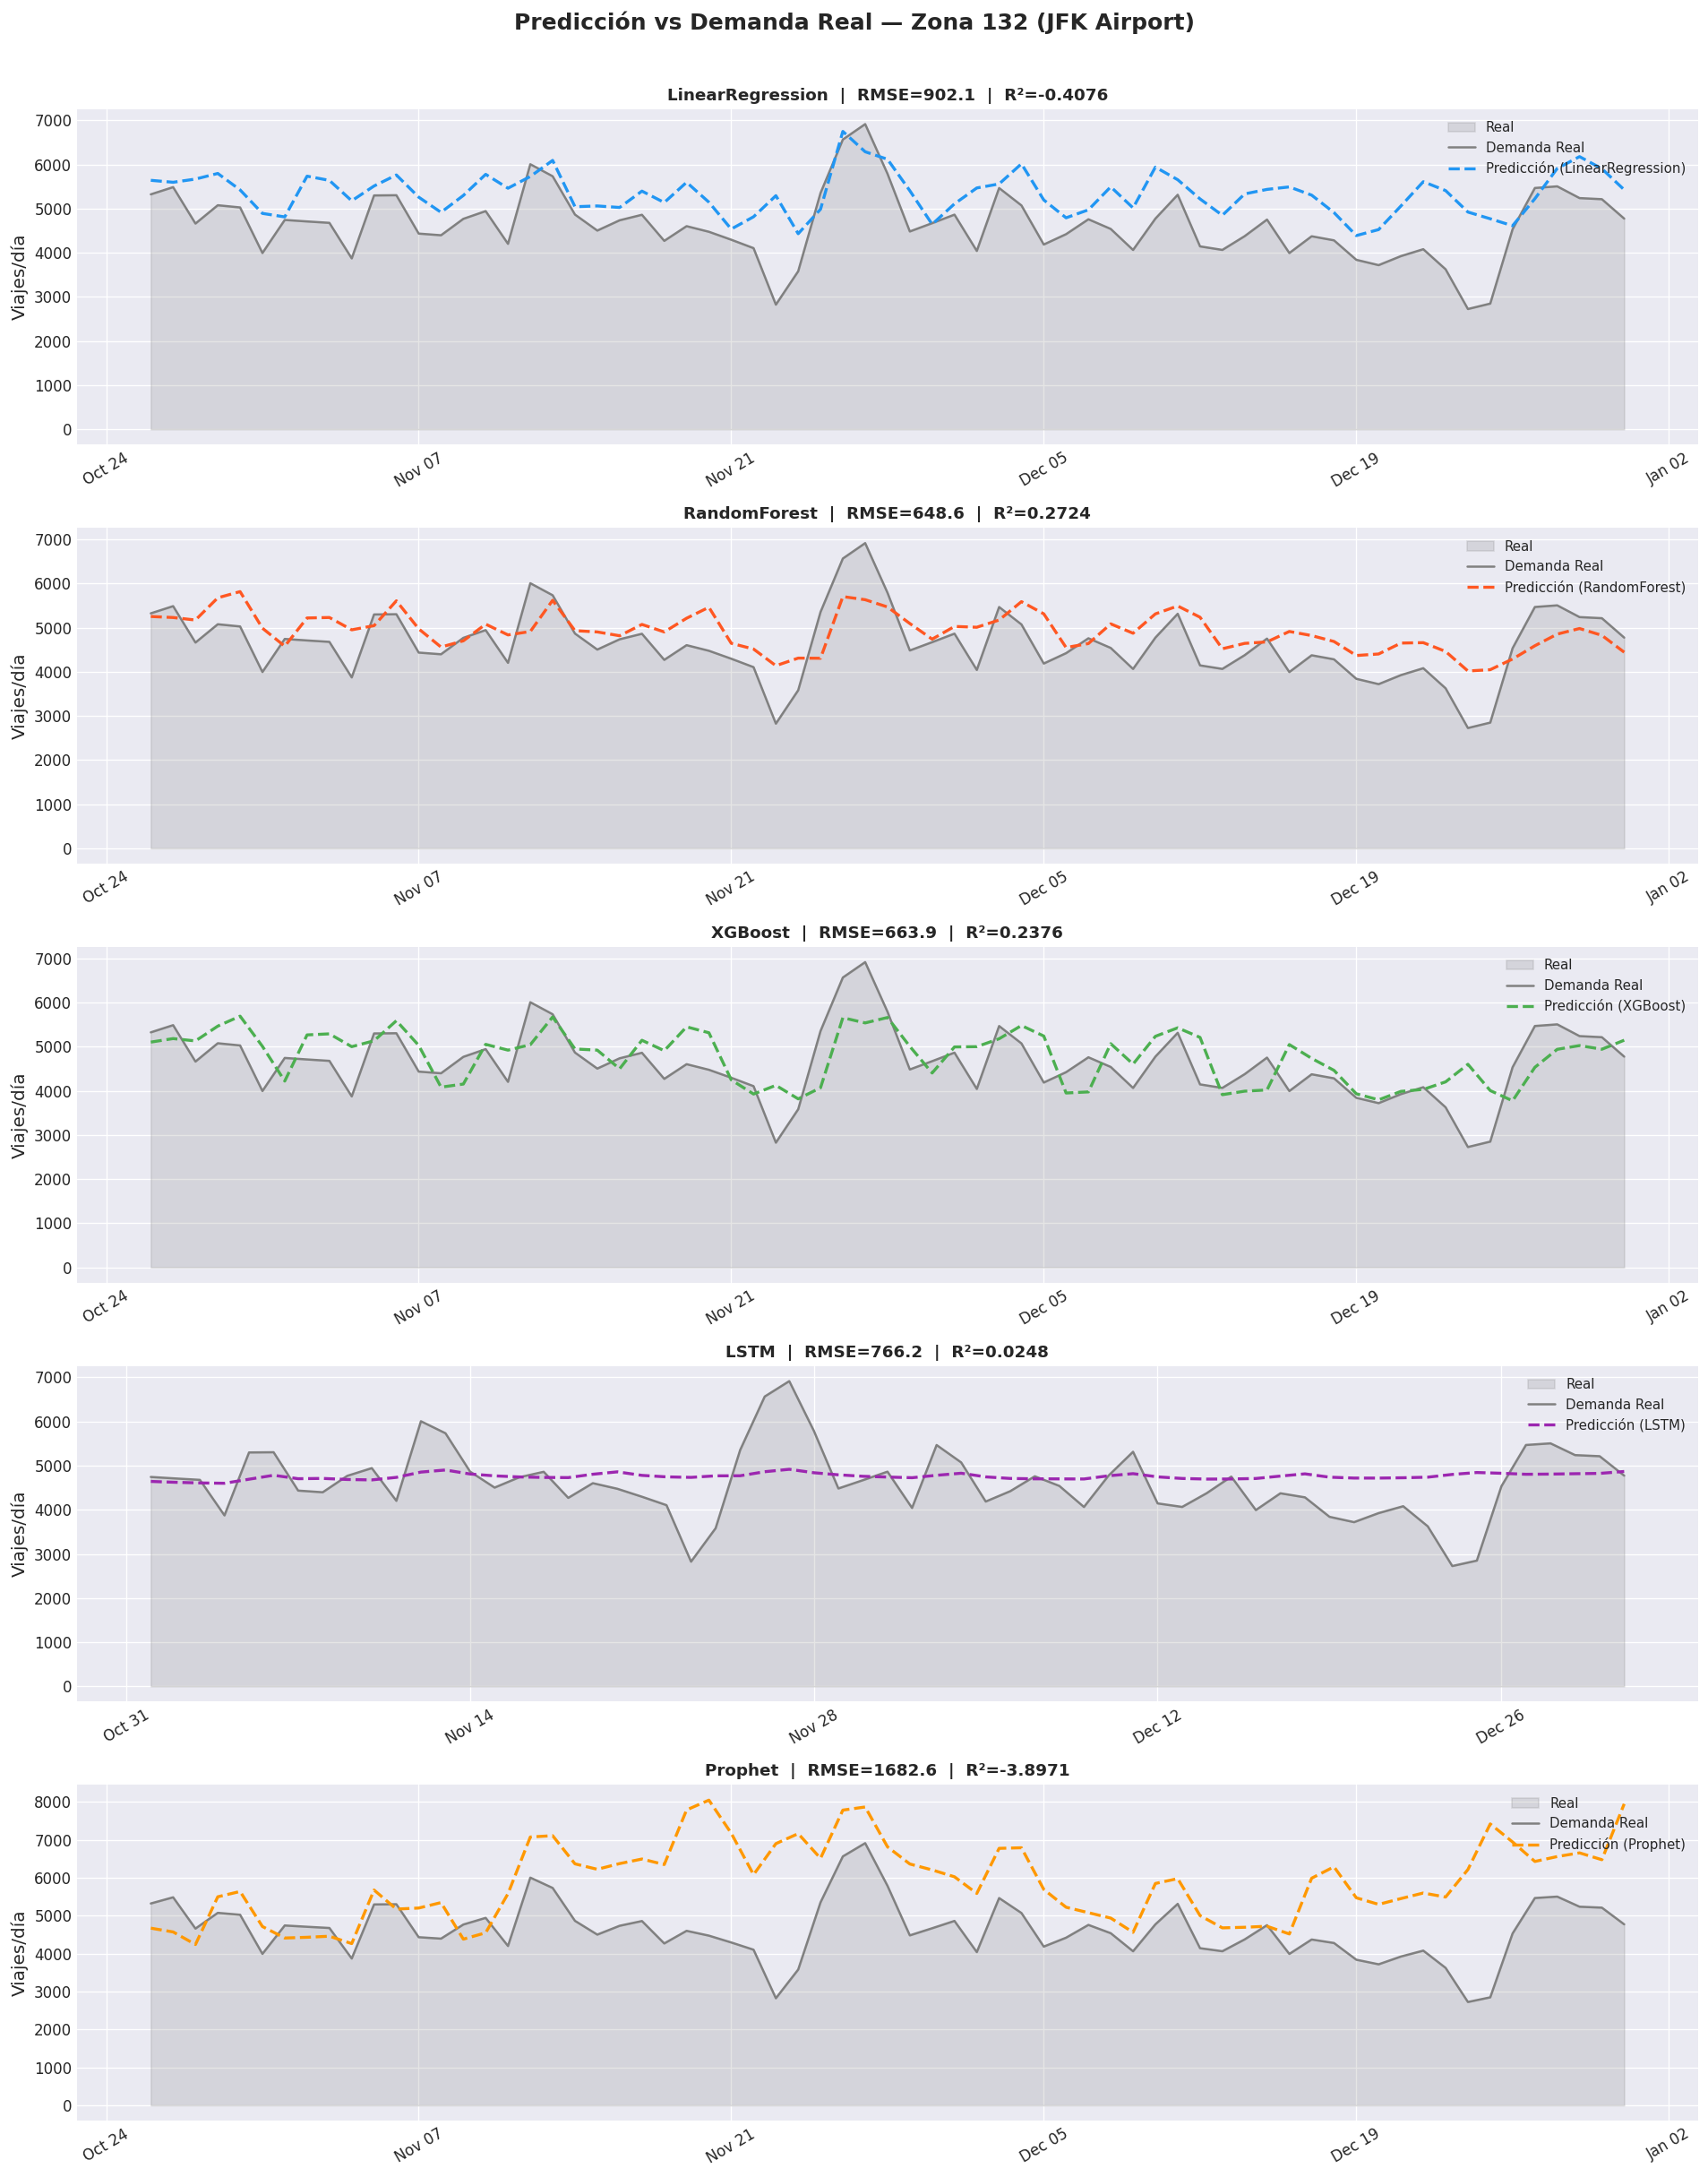

In [63]:
# ══════════════════════════════════════════════════════════════════════════════
# 9.2  GRÁFICAS PRED vs REAL — Todos los modelos, zona principal
# ══════════════════════════════════════════════════════════════════════════════

MODELS_TO_PLOT = ['LinearRegression', 'RandomForest', 'XGBoost', 'LSTM', 'Prophet']
MODEL_COLORS   = dict(zip(MODELS_TO_PLOT, PALETTE))

fig, axes = plt.subplots(len(MODELS_TO_PLOT), 1, figsize=(16, 4*len(MODELS_TO_PLOT)))
fig.suptitle(
    f'Predicción vs Demanda Real — Zona {PRIMARY_ZONE} ({ZONE_NAMES.get(PRIMARY_ZONE, "")})',
    fontsize=15, fontweight='bold', y=1.01
)

for ax, model_name in zip(axes, MODELS_TO_PLOT):
    key = (PRIMARY_ZONE, model_name)
    if key not in predictions_store:
        ax.set_visible(False)
        continue

    preds = predictions_store[key]
    dates  = pd.to_datetime(preds['dates'])
    y_true = preds['y_true']
    y_pred = preds['y_pred']

    # Métricas de este modelo
    m_row = results_df[(results_df['model'] == model_name) & (results_df['zone_id'] == PRIMARY_ZONE)]
    rmse_val = m_row['RMSE'].values[0] if len(m_row) > 0 else 0
    r2_val   = m_row['R2'].values[0]   if len(m_row) > 0 else 0

    ax.fill_between(dates, y_true, alpha=0.2, color='gray', label='Real')
    ax.plot(dates, y_true, color='gray', linewidth=1.5, label='Demanda Real')
    ax.plot(dates, y_pred, color=MODEL_COLORS[model_name], linewidth=2,
            linestyle='--', label=f'Predicción ({model_name})')

    ax.set_title(f'{model_name}  |  RMSE={rmse_val:.1f}  |  R²={r2_val:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Viajes/día')
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_pred_vs_real.png', bbox_inches='tight', dpi=150)
plt.show()

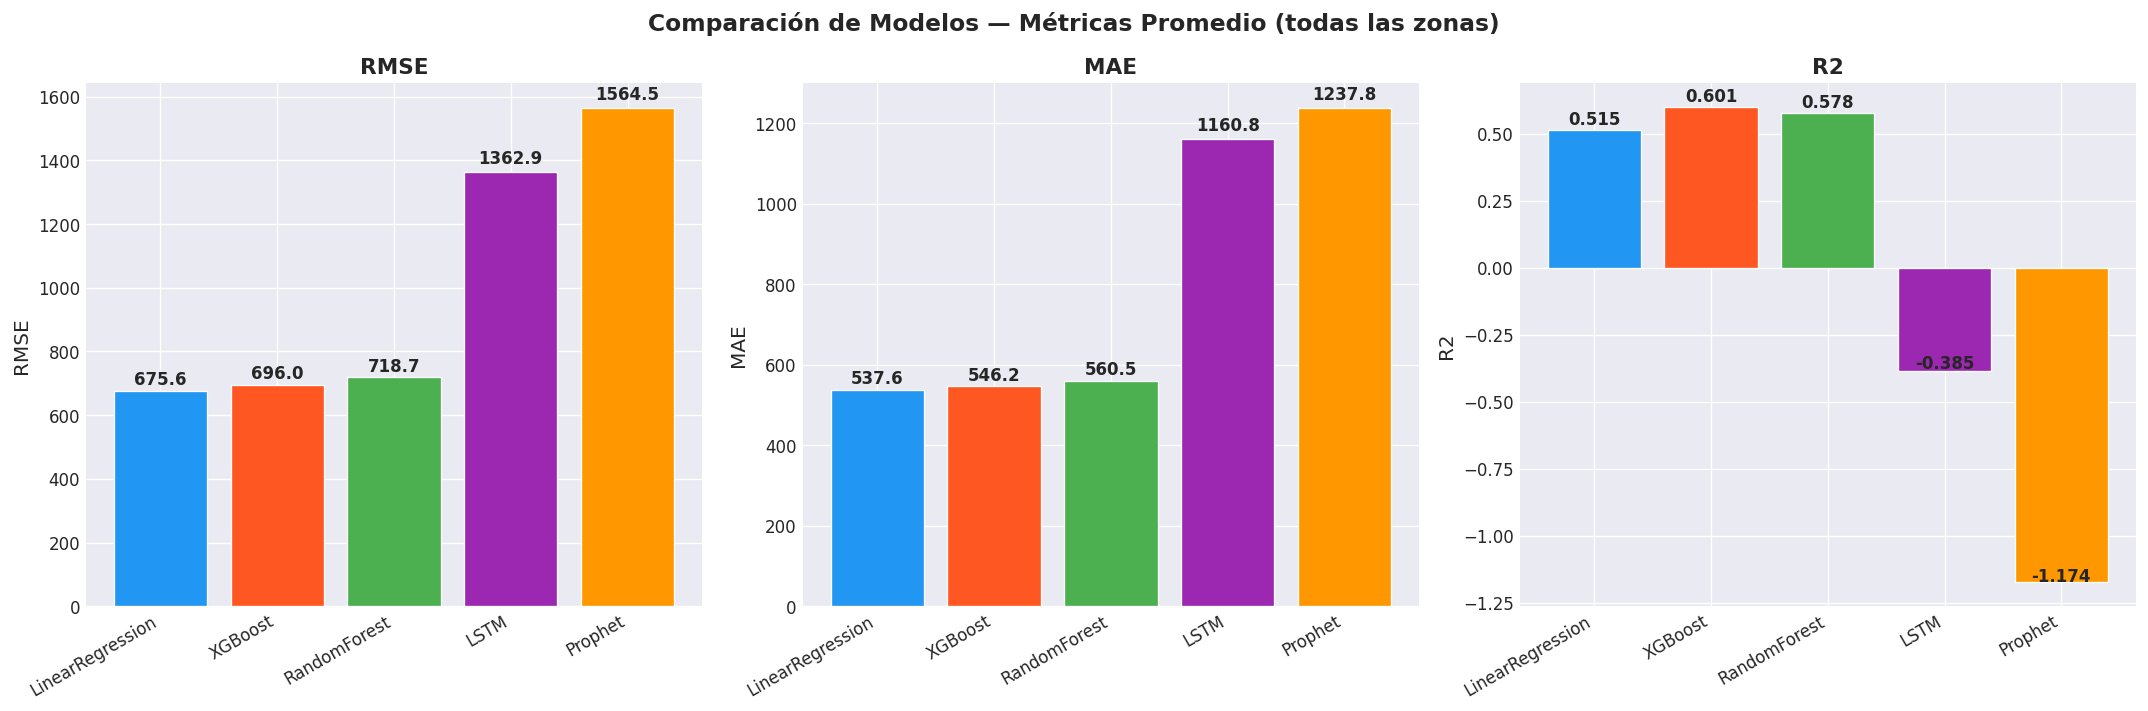

In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# 9.3  BARPLOT COMPARATIVO DE RMSE Y MAE
# ══════════════════════════════════════════════════════════════════════════════

avg_metrics = results_df.groupby('model')[['RMSE', 'MAE', 'R2']].mean().sort_values('RMSE')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Modelos — Métricas Promedio (todas las zonas)',
             fontsize=14, fontweight='bold')

for ax, (metric, color_map) in zip(axes, [('RMSE', PALETTE[1]), ('MAE', PALETTE[0]), ('R2', PALETTE[2])]):
    bars = ax.bar(
        avg_metrics.index,
        avg_metrics[metric],
        color=[PALETTE[i % len(PALETTE)] for i in range(len(avg_metrics))],
        edgecolor='white', linewidth=0.8
    )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(avg_metrics.index, rotation=30, ha='right')
    for bar, val in zip(bars, avg_metrics[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*bar.get_height(),
                f'{val:.1f}' if metric != 'R2' else f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Predicción Final: Próximos 30 Días <a id='10'></a>

In [65]:
# ══════════════════════════════════════════════════════════════════════════════
# 10.1  IDENTIFICAR MEJOR MODELO POR ZONA
# ══════════════════════════════════════════════════════════════════════════════

best_models_by_zone = (
    results_df.sort_values(['zone_id', 'RMSE'])
    .groupby('zone_id')
    .first()
    .reset_index()[['zone_id', 'model', 'RMSE', 'R2']]
)

print('🏆 Mejor modelo por zona:')
display(best_models_by_zone)

🏆 Mejor modelo por zona:


,zone_id,model,RMSE,R2
0,132,RandomForest,648.6,0.2724
1,161,XGBoost,756.5,0.6470
2,162,LinearRegression,493.2,0.7508
3,236,LinearRegression,510.1,0.8438
4,237,LinearRegression,624.8,0.8303


In [66]:
# ══════════════════════════════════════════════════════════════════════════════
# 10.2  FORECAST 30 DÍAS — Usando el mejor modelo de cada zona
# Estrategia: usamos Prophet para el forecast nativo de 30 días
# y XGBoost con features rolling para modelos de ML
# ══════════════════════════════════════════════════════════════════════════════

FORECAST_DAYS = 30
forecast_results = {}

for zone_id in top_zones:
    zone_data = (
        daily[daily['PULocationID'] == zone_id]
        .sort_values('pickup_date')
        [['pickup_date', 'trips', 'holiday_flag']]
        .rename(columns={'pickup_date': 'ds', 'trips': 'y', 'holiday_flag': 'is_holiday'})
    )
    
    # Feriados
    us_hol_2024 = holidays.US(state='NY', years=2024)
    holiday_df = pd.concat([
        zone_data[zone_data['is_holiday'] == 1][['ds']],
        pd.DataFrame({'ds': pd.to_datetime(list(us_hol_2024.keys()))})
    ]).drop_duplicates()
    holiday_df['holiday'] = 'US_Holiday'
    holiday_df['lower_window'] = -1
    holiday_df['upper_window'] = 1
    
    # Reentrenar Prophet con todos los datos
    m = Prophet(
        seasonality_mode='multiplicative',
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
        holidays=holiday_df,
        changepoint_prior_scale=0.05,
        interval_width=0.90,
    )
    m.fit(zone_data[['ds', 'y']])
    
    # Forecast
    future   = m.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
    forecast = m.predict(future)
    
    # Extraer los últimos 30 días (el horizonte futuro)
    fc_30 = forecast.tail(FORECAST_DAYS)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    fc_30['yhat']       = np.maximum(fc_30['yhat'],       0)
    fc_30['yhat_lower'] = np.maximum(fc_30['yhat_lower'], 0)
    fc_30['yhat_upper'] = np.maximum(fc_30['yhat_upper'], 0)
    fc_30['zone_id']    = zone_id
    fc_30['zone_name']  = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')
    
    forecast_results[zone_id] = fc_30
    print(f'✅ Zona {zone_id} — pronóstico generado para {FORECAST_DAYS} días')

forecast_all = pd.concat(forecast_results.values(), ignore_index=True)
print(f'\n📅 Total predicciones: {len(forecast_all)}')
display(forecast_all.head(10))

21:16:00 - cmdstanpy - INFO - Chain [1] start processing
21:16:00 - cmdstanpy - INFO - Chain [1] done processing
21:16:00 - cmdstanpy - INFO - Chain [1] start processing
21:16:00 - cmdstanpy - INFO - Chain [1] done processing


✅ Zona 132 — pronóstico generado para 30 días


21:16:00 - cmdstanpy - INFO - Chain [1] start processing
21:16:00 - cmdstanpy - INFO - Chain [1] done processing


✅ Zona 237 — pronóstico generado para 30 días


21:16:01 - cmdstanpy - INFO - Chain [1] start processing
21:16:01 - cmdstanpy - INFO - Chain [1] done processing


✅ Zona 161 — pronóstico generado para 30 días


21:16:01 - cmdstanpy - INFO - Chain [1] start processing
21:16:01 - cmdstanpy - INFO - Chain [1] done processing


✅ Zona 236 — pronóstico generado para 30 días
✅ Zona 162 — pronóstico generado para 30 días

📅 Total predicciones: 150


,ds,yhat,yhat_lower,yhat_upper,zone_id,zone_name
0,2024-01-01,5634.378251,4686.049944,6793.093967,132,JFK Airport
1,2024-01-02,5333.442236,4297.196769,6336.263318,132,JFK Airport
2,2024-01-03,4931.557974,3928.671569,5897.025488,132,JFK Airport
3,2024-01-04,5034.995669,4080.661272,6030.287302,132,JFK Airport
4,2024-01-05,5114.219357,4050.130198,6129.715801,132,JFK Airport
5,2024-01-06,4870.099435,3851.918698,5941.875458,132,JFK Airport
6,2024-01-07,6044.622034,5033.072636,7143.299723,132,JFK Airport
7,2024-01-08,6287.413805,5240.251671,7318.747822,132,JFK Airport
8,2024-01-09,5467.115047,4372.238218,6487.396879,132,JFK Airport
9,2024-01-10,5257.808987,4178.158932,6319.704613,132,JFK Airport


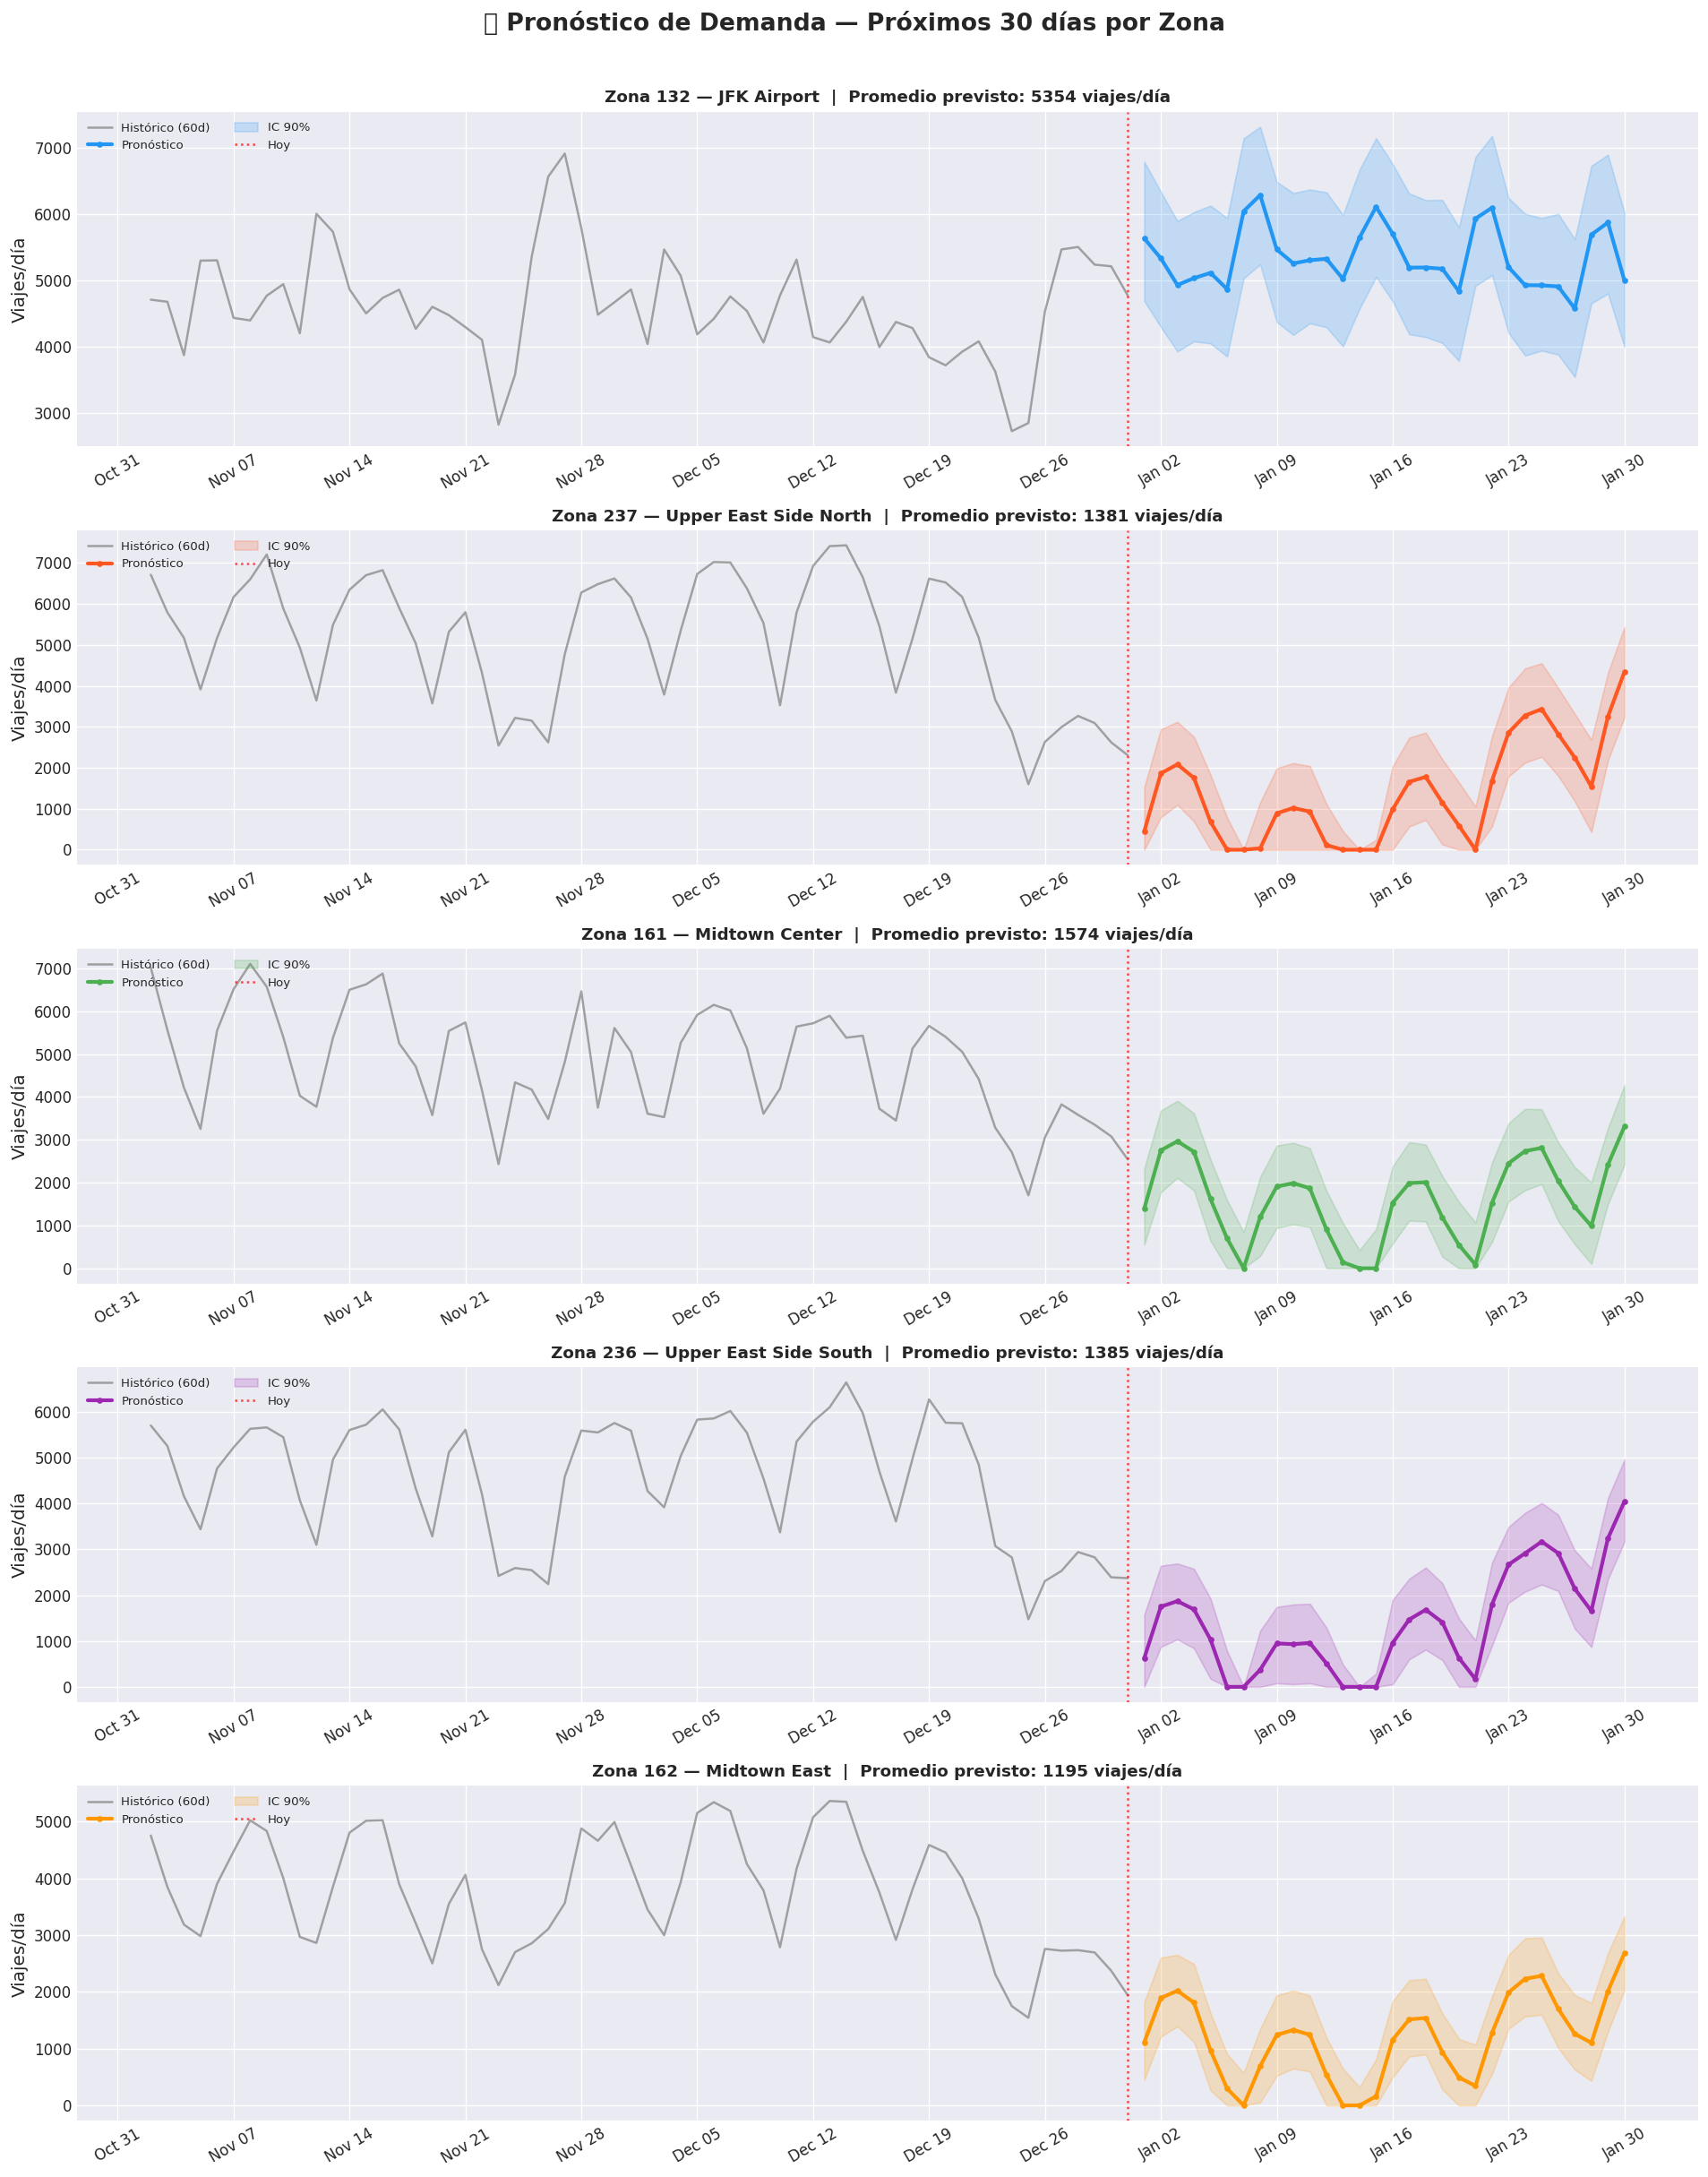

In [67]:
# ══════════════════════════════════════════════════════════════════════════════
# 10.3  GRÁFICA FORECAST 30 DÍAS POR RUTA
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(TOP_N_ZONES, 1, figsize=(16, 4*TOP_N_ZONES))
fig.suptitle(
    f'📅 Pronóstico de Demanda — Próximos {FORECAST_DAYS} días por Zona',
    fontsize=16, fontweight='bold', y=1.01
)

for ax, (zone_id, color) in zip(axes, zip(top_zones, PALETTE)):
    # Historia reciente (último mes)
    hist = (
        daily[daily['PULocationID'] == zone_id]
        .sort_values('pickup_date')
        .tail(60)
    )
    fc = forecast_results[zone_id]
    zone_name = ZONE_NAMES.get(zone_id, f'Zone {zone_id}')

    # Historia
    ax.plot(hist['pickup_date'], hist['trips'],
            color='gray', linewidth=1.5, alpha=0.7, label='Histórico (60d)')

    # Pronóstico
    ax.plot(fc['ds'], fc['yhat'], color=color, linewidth=2.5,
            marker='o', markersize=3, label='Pronóstico')

    # Intervalo de confianza 90%
    ax.fill_between(
        fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
        alpha=0.2, color=color, label='IC 90%'
    )

    # Línea divisora historia/futuro
    ax.axvline(hist['pickup_date'].max(), color='red',
               linestyle=':', linewidth=1.5, alpha=0.7, label='Hoy')

    # Estadísticas del pronóstico
    avg_fc = fc['yhat'].mean()
    ax.set_title(
        f'Zona {zone_id} — {zone_name}  |  Promedio previsto: {avg_fc:.0f} viajes/día',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Viajes/día')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_forecast_30dias.png', bbox_inches='tight', dpi=150)
plt.show()

In [68]:
# ══════════════════════════════════════════════════════════════════════════════
# 10.4  TABLA RESUMEN OPERACIONAL — Para gerencia de transporte
# ══════════════════════════════════════════════════════════════════════════════

print('\n🚖 RESUMEN OPERACIONAL — Demanda Pronosticada (30 días)')
print('Para planificación de flota y personal\n')

PASSENGERS_PER_VEHICLE = 4   # promedio de ocupación
TRIPS_PER_DRIVER_DAY   = 25  # viajes promedio por conductor/día

summary_rows = []
for zone_id in top_zones:
    fc = forecast_results[zone_id]
    avg_daily  = fc['yhat'].mean()
    peak_daily = fc['yhat'].max()
    low_daily  = fc['yhat'].min()
    total_30   = fc['yhat'].sum()
    vehicles_needed = int(np.ceil(peak_daily / TRIPS_PER_DRIVER_DAY))
    drivers_needed  = vehicles_needed

    summary_rows.append({
        'Zona ID':        zone_id,
        'Nombre':         ZONE_NAMES.get(zone_id, f'Zone {zone_id}')[:30],
        'Prom. diario':   f'{avg_daily:.0f}',
        'Pico diario':    f'{peak_daily:.0f}',
        'Mínimo diario':  f'{low_daily:.0f}',
        'Total 30 días':  f'{total_30:.0f}',
        'Vehículos peak': vehicles_needed,
        'Conductores':    drivers_needed,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.set_properties(**{'text-align': 'center'}))

# Guardar CSV
forecast_all.to_csv(f'{OUTPUT_DIR}/forecast_30dias.csv', index=False)
summary_df.to_csv(f'{OUTPUT_DIR}/resumen_operacional.csv', index=False)
print('\n✅ Archivos guardados: forecast_30dias.csv | resumen_operacional.csv')


🚖 RESUMEN OPERACIONAL — Demanda Pronosticada (30 días)
Para planificación de flota y personal



,Zona ID,Nombre,Prom. diario,Pico diario,Mínimo diario,Total 30 días,Vehículos peak,Conductores
0,132,JFK Airport,5354,6287,4576,160621,252,252
1,237,Upper East Side North,1381,4345,0,41428,174,174
2,161,Midtown Center,1574,3314,0,47221,133,133
3,236,Upper East Side South,1385,4044,0,41541,162,162
4,162,Midtown East,1195,2686,0,35846,108,108



✅ Archivos guardados: forecast_30dias.csv | resumen_operacional.csv


## 11. Conclusiones y Recomendaciones <a id='11'></a>

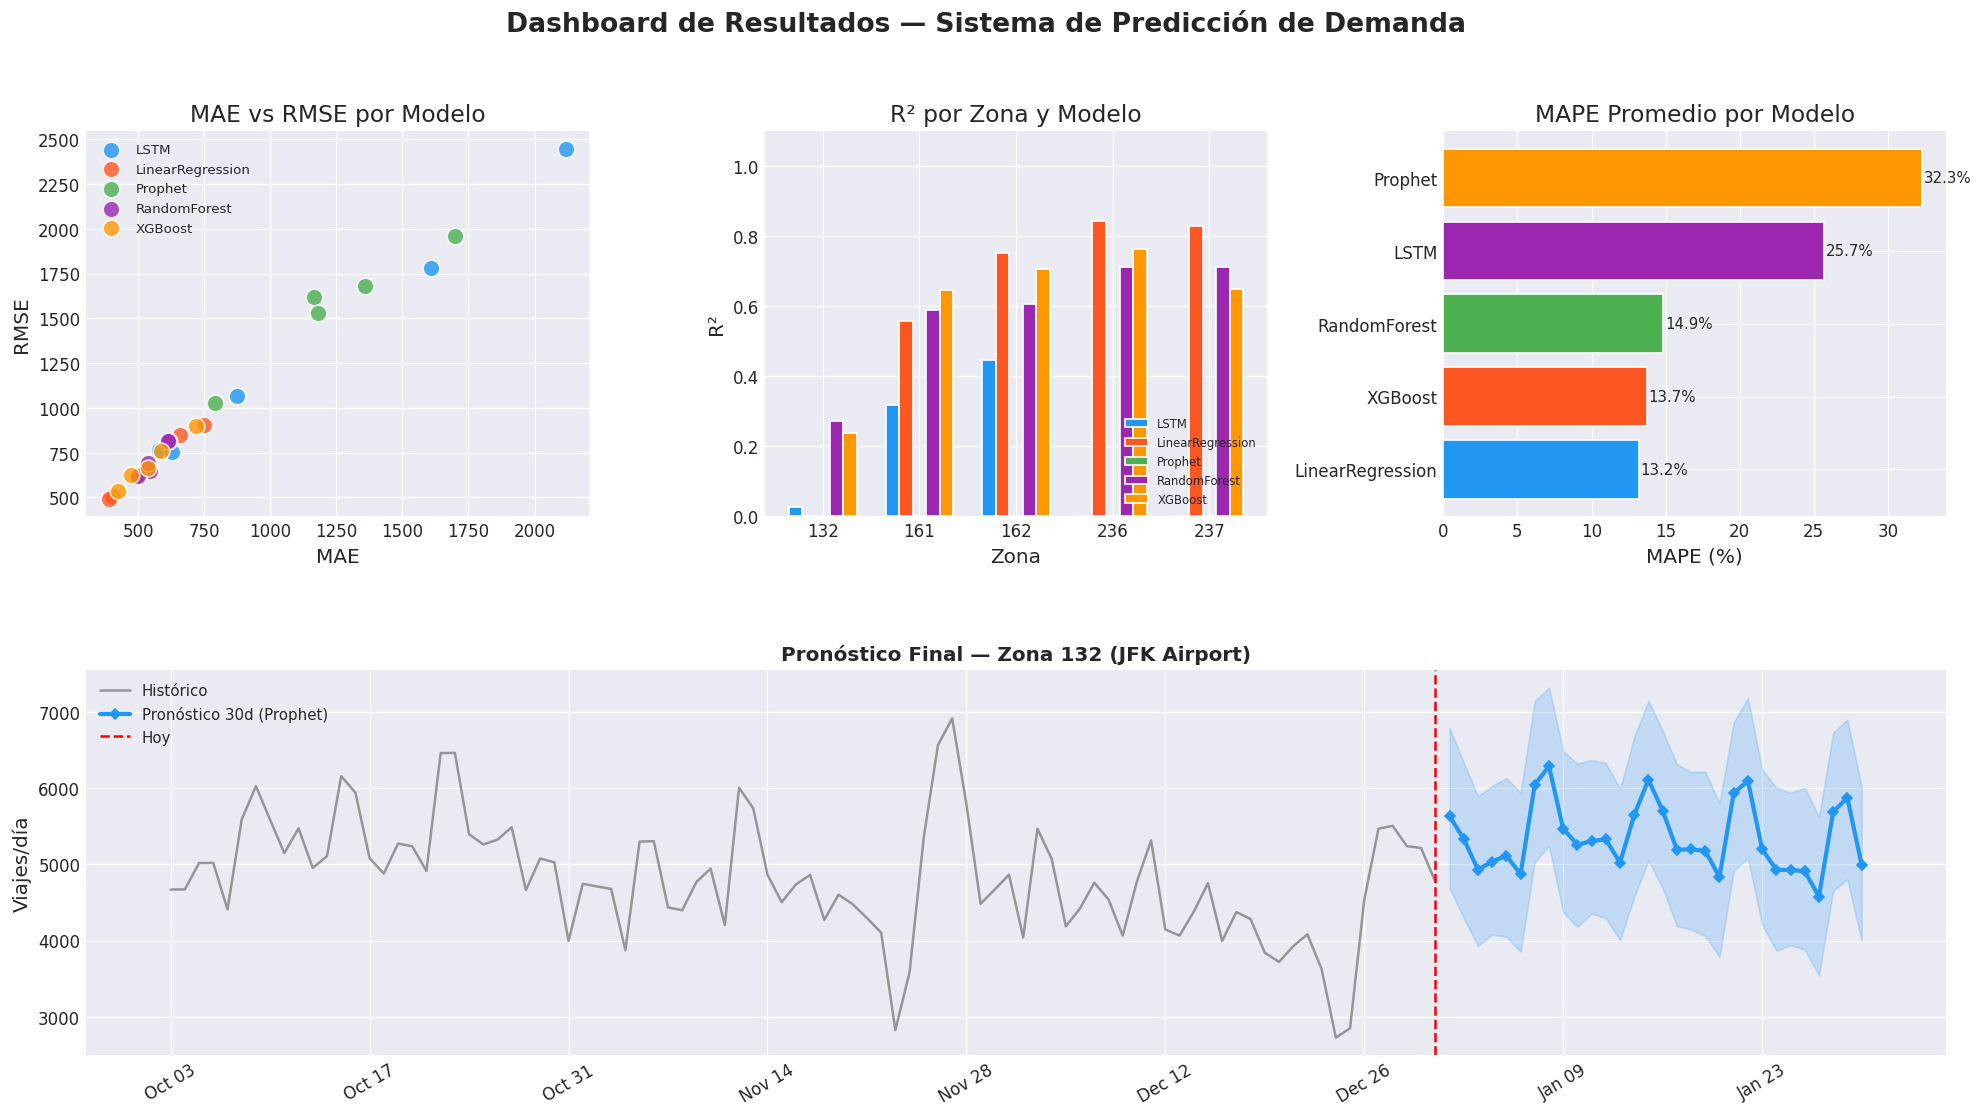

✅ Dashboard final guardado


In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# 11.1  GRÁFICA FINAL — Resumen de rendimiento de todos los modelos
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

fig.suptitle('Dashboard de Resultados — Sistema de Predicción de Demanda',
             fontsize=16, fontweight='bold')

# ── Plot 1: RMSE por modelo (scatter) ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for i, (model_name, grp) in enumerate(results_df.groupby('model')):
    ax1.scatter(grp['MAE'], grp['RMSE'], label=model_name,
                color=PALETTE[i], s=100, alpha=0.8, edgecolors='white', linewidth=1)
ax1.set_xlabel('MAE')
ax1.set_ylabel('RMSE')
ax1.set_title('MAE vs RMSE por Modelo')
ax1.legend(fontsize=8)

# ── Plot 2: R² por zona ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
r2_pivot = results_df.pivot_table(index='zone_id', columns='model', values='R2')
r2_pivot.plot(kind='bar', ax=ax2, color=PALETTE[:len(r2_pivot.columns)],
              edgecolor='white', width=0.7)
ax2.set_title('R² por Zona y Modelo')
ax2.set_xlabel('Zona')
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=7, loc='lower right')
ax2.set_xticklabels(r2_pivot.index, rotation=0)

# ── Plot 3: MAPE por modelo ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
mape_avg = results_df.groupby('model')['MAPE'].mean().sort_values()
bars = ax3.barh(mape_avg.index, mape_avg.values,
                color=[PALETTE[i] for i in range(len(mape_avg))], edgecolor='white')
ax3.set_title('MAPE Promedio por Modelo')
ax3.set_xlabel('MAPE (%)')
for bar, val in zip(bars, mape_avg.values):
    ax3.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

# ── Plot 4: Forecast comparado zona principal ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
fc_main = forecast_results[PRIMARY_ZONE]
hist_main = daily[daily['PULocationID'] == PRIMARY_ZONE].sort_values('pickup_date').tail(90)

ax4.plot(hist_main['pickup_date'], hist_main['trips'],
         color='gray', linewidth=1.5, label='Histórico', alpha=0.8)
ax4.fill_between(fc_main['ds'], fc_main['yhat_lower'], fc_main['yhat_upper'],
                 alpha=0.2, color=PALETTE[0])
ax4.plot(fc_main['ds'], fc_main['yhat'], color=PALETTE[0], linewidth=2.5,
         label='Pronóstico 30d (Prophet)', marker='D', markersize=4)
ax4.axvline(hist_main['pickup_date'].max(), color='red',
            linestyle='--', linewidth=1.5, label='Hoy')
ax4.set_title(f'Pronóstico Final — Zona {PRIMARY_ZONE} ({ZONE_NAMES.get(PRIMARY_ZONE, "")})',
              fontsize=12, fontweight='bold')
ax4.set_ylabel('Viajes/día')
ax4.legend(fontsize=9)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax4.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30)

plt.savefig(f'{OUTPUT_DIR}/10_dashboard_final.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Dashboard final guardado')

## 12. Guardado de Modelos y Exportación de Resultados <a id='12'></a>

In [ ]:
(MODELS_DIR / 'xgb').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'rf').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'lr').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'prophet').mkdir(parents=True, exist_ok=True)

# Ahora sí, el guardado funcionará sin problemas
for zone_id in top_zones:
    joblib.dump(xgb_models[zone_id], filename=MODELS_DIR / f'xgb/xgb_zone_{zone_id}.pkl')
    joblib.dump(rf_models[zone_id],  filename=MODELS_DIR / f'rf/rf_zone_{zone_id}.pkl')
    joblib.dump(lr_models[zone_id],  filename=MODELS_DIR / f'lr/lr_zone_{zone_id}.pkl')

# Lo mismo para Prophet
for zone_id in top_zones:
    model_path = MODELS_DIR / f'prophet/prophet_zone_{zone_id}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(prophet_models[zone_id][0], f)
print('✅ Modelos guardados correctamente en la carpeta "models"')

✅ Modelos guardados correctamente en la carpeta "models"


In [77]:
# Scalers del LSTM (necesarios para desnormalizar en producción)
(MODELS_DIR / 'lstm').mkdir(parents=True, exist_ok=True)

for zone_id in top_zones:
    joblib.dump(lstm_scalers[zone_id], filename=MODELS_DIR / f'lstm/scaler_zone_{zone_id}.pkl')

# Metadata: zonas, features, parámetros — lo que la API necesita saber
metadata = {
    'top_zones':     top_zones,
    'zone_names':    {str(k): v for k, v in ZONE_NAMES.items()},
    'feature_cols':  FEATURE_COLS,
    'lstm_features': LSTM_FEATURES,
    'seq_len':       SEQ_LEN,
    'forecast_days': FORECAST_DAYS,
}
with open(MODELS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Modelos y metadata exportados para producción')

✅ Modelos y metadata exportados para producción


In [81]:
charts_data = {}
for zone_id in top_zones:
    charts_data[str(zone_id)] = {}
    for model_name in ['LinearRegression', 'RandomForest', 'XGBoost', 'LSTM', 'Prophet']:
        key = (zone_id, model_name)
        if key not in predictions_store:
            continue
        preds = predictions_store[key]
        charts_data[str(zone_id)][model_name] = {
            'dates':  [str(d)[:10] for d in preds['dates']],
            'y_true': preds['y_true'].tolist(),
            'y_pred': preds['y_pred'].tolist(),
        }

with open(MODELS_DIR / 'predictions_chart_data.json', 'w') as f:
    json.dump(charts_data, f)

# También el forecast de 30 días
forecast_export = {}
for zone_id in top_zones:
    fc = forecast_results[zone_id]
    forecast_export[str(zone_id)] = {
        'dates':       fc['ds'].dt.strftime('%Y-%m-%d').tolist(),
        'yhat':        fc['yhat'].round(1).tolist(),
        'yhat_lower':  fc['yhat_lower'].round(1).tolist(),
        'yhat_upper':  fc['yhat_upper'].round(1).tolist(),
        'zone_name':   ZONE_NAMES.get(zone_id, f'Zone {zone_id}'),
    }

with open(MODELS_DIR / 'forecast_export.json', 'w') as f:
    json.dump(forecast_export, f)

print('✅ JSON de gráficas exportado')

✅ JSON de gráficas exportado
